# 06 — Linear and Polynomial Regression
### From Supervised Learning Theory to Ridge Regularization

---

> **Position in the series:**
> `01_statistical_learning_theory` → `02_pac_and_vc_dimensions` → `03_linear_algebra_and_geometry` → `04_pca` → `05_gaussian_mixture_models` → **`06_linear_regression`** → `07_logistic_regression` → `08_svm_and_kernel_methods`

---

## References

| # | Source |
|---|--------|
| [1] | Andrew Ng — *CS229 Lecture Notes*, Stanford University (2019) |
| [2] | Iacopo Masi — *07_regression lecture slides & 11_regression_lsq_poly notebook*, Sapienza SMIA |
| [3] | C. M. Bishop — *Pattern Recognition and Machine Learning*, Springer, 2006 — Ch. 1, 3 |
| [4] | S. Shalev-Shwartz & S. Ben-David — *Understanding Machine Learning*, Cambridge, 2014 — Ch. 9 |
| [5] | G. H. Golub & C. F. Van Loan — *Matrix Computations*, 4th ed., Johns Hopkins, 2013 |
| [6] | C. R. Rao — *Linear Statistical Inference and Its Applications*, 2nd ed., Wiley, 1973 — Ch. 4 *(Gauss-Markov Theorem)* |
| [7] | F. J. Anscombe — *Graphs in Statistical Analysis*, The American Statistician, 27(1), 1973 *(Residual Analysis)* |
| [8] | D. A. Belsley, E. Kuh & R. E. Welsch — *Regression Diagnostics*, Wiley, 1980 — Ch. 3 *(Multicollinearity)* |

---

## Structure
1. Supervised Learning Framework & Underfitting vs. Overfitting
2. Generative Assumption: Gaussian Noise
3. The Linear Model & Augmented Vector Trick
4. Objective Function: Residual Sum of Squares
5. From True Risk to ERM — Dimensional Analysis
6. Three Roads to $\mathbf{w}^*$
   - 6A. Analytical: Normal Equations (full derivation)
   - 6B. Geometric: Orthogonal Projection & Hat Matrix
   - 6C. Probabilistic: MLE
7. **Gauss-Markov Theorem: OLS is BLUE** *(new)*
8. Iterative Optimization: Gradient Descent
9. Polynomial Regression & Vandermonde Matrix
10. Overfitting Diagnostics & Bias-Variance Trade-off
11. Ridge Regularization — Spectral Analysis
12. Expected Value of the Ridge Estimator
13. **Residual Analysis: Validating Model Assumptions** *(new)*
14. **Multicollinearity: Causes, Diagnosis, Remedy** *(new)*
15. Linear vs. Polynomial vs. Ridge — Full Comparison


---
## 1. Supervised Learning Framework & Underfitting vs. Overfitting

In the context of **Supervised Learning**, we operate with a training dataset consisting of $N$ pairs of inputs and their corresponding continuous targets:

$$\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$$

* **Input Space ($\mathcal{X}$):** Each input vector $\mathbf{x}_i \in \mathbb{R}^d$ represents a set of features.
* **Target Space ($\mathcal{Y}$):** The target $y_i \in \mathbb{R}$ is a continuous scalar.
* **Hypothesis Space ($\mathcal{H}$):** The set of all possible functions $f: \mathcal{X} \rightarrow \mathcal{Y}$ our model can assume. Our goal is to find $f^* \in \mathcal{H}$ that minimizes structural errors and generalizes to unseen data.

### Fundamental Challenge: Underfitting vs. Overfitting

* **Underfitting (High Bias):** $\mathcal{H}$ too restrictive — model fails to capture the underlying trend → high training error and high test error.
* **Overfitting (High Variance):** Excessive capacity relative to data — model memorizes training samples including their random noise → near-zero training error but massive test error.

> **ML Bridge:** This tension is formalized by the **Bias-Variance decomposition** (Section 10) and bounded in theory by the VC dimension (see `02_pac_and_vc_dimensions`).


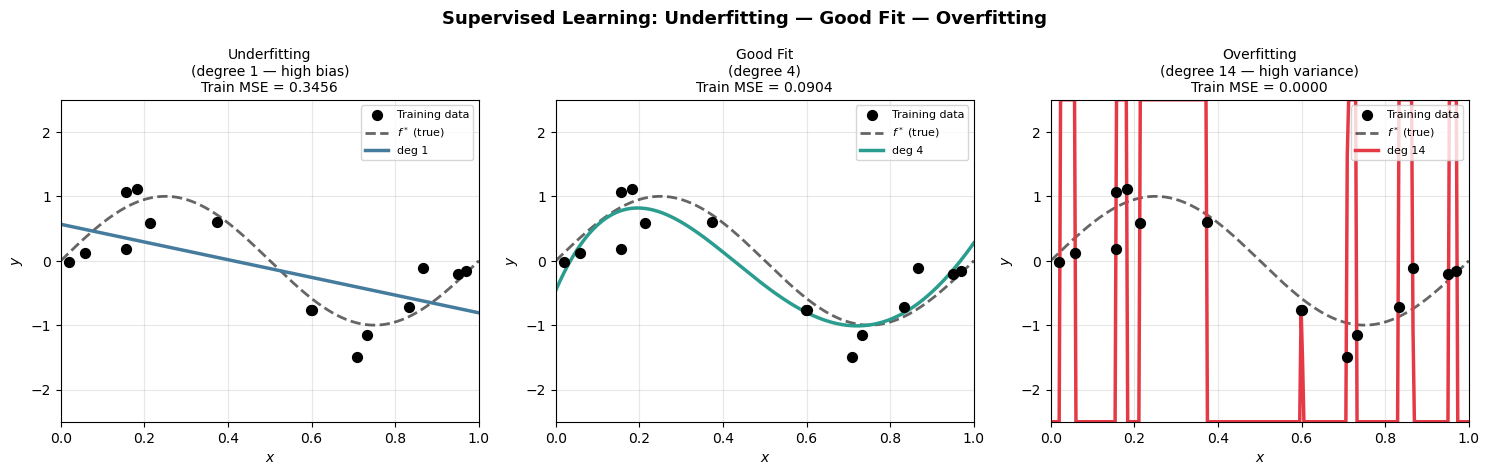

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

np.random.seed(42)
f_star  = lambda x: np.sin(2 * np.pi * x)
N_train = 15
x_train = np.sort(np.random.uniform(0, 1, N_train))
y_train = f_star(x_train) + np.random.normal(0, 0.25, N_train)
x_plot  = np.linspace(0, 1, 300)

degrees = [1, 4, 14]
titles  = ['Underfitting\n(degree 1 — high bias)', 'Good Fit\n(degree 4)', 'Overfitting\n(degree 14 — high variance)']
colors  = ['#457B9D', '#2A9D8F', '#E63946']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, deg, title, color in zip(axes, degrees, titles, colors):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(x_train.reshape(-1,1), y_train)
    mse = mean_squared_error(y_train, model.predict(x_train.reshape(-1,1)))
    ax.scatter(x_train, y_train, s=50, color='black', zorder=5, label='Training data')
    ax.plot(x_plot, f_star(x_plot), 'k--', lw=2, alpha=0.6, label=r'$f^*$ (true)')
    ax.plot(x_plot, np.clip(model.predict(x_plot.reshape(-1,1)), -2.5, 2.5), color=color, lw=2.5, label=f'deg {deg}')
    ax.set_xlim(0,1); ax.set_ylim(-2.5,2.5)
    ax.set_title(f'{title}\nTrain MSE = {mse:.4f}', fontsize=10)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Supervised Learning: Underfitting — Good Fit — Overfitting', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 2. Generative Assumption: The Role of Gaussian Noise

We model the data-generating process as:

$$y = f(\mathbf{x}) + \epsilon, \qquad \epsilon \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0, \sigma^2)$$

Each noise term has density $p(\epsilon) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{\epsilon^2}{2\sigma^2}\right)$, implying:

$$y_i \mid \mathbf{x}_i \sim \mathcal{N}(f(\mathbf{x}_i),\, \sigma^2)$$

### Key Clarification on Variance and Overfitting

The variance $\sigma^2$ is completely **aleatoric** (irreducible). The model cannot learn this noise because $\mathbb{E}[\epsilon]=0$. **Overfitting does not happen because we study $\sigma^2$**; it occurs because a high-capacity model shapes its parameters around the *specific random instances* of $\epsilon$ in the training set.

> **Connection to PCA (04):** This is the same noise model used in Probabilistic PCA: $\mathbf{x} = \mathbf{W}\mathbf{z} + \boldsymbol{\mu} + \boldsymbol{\epsilon}$.


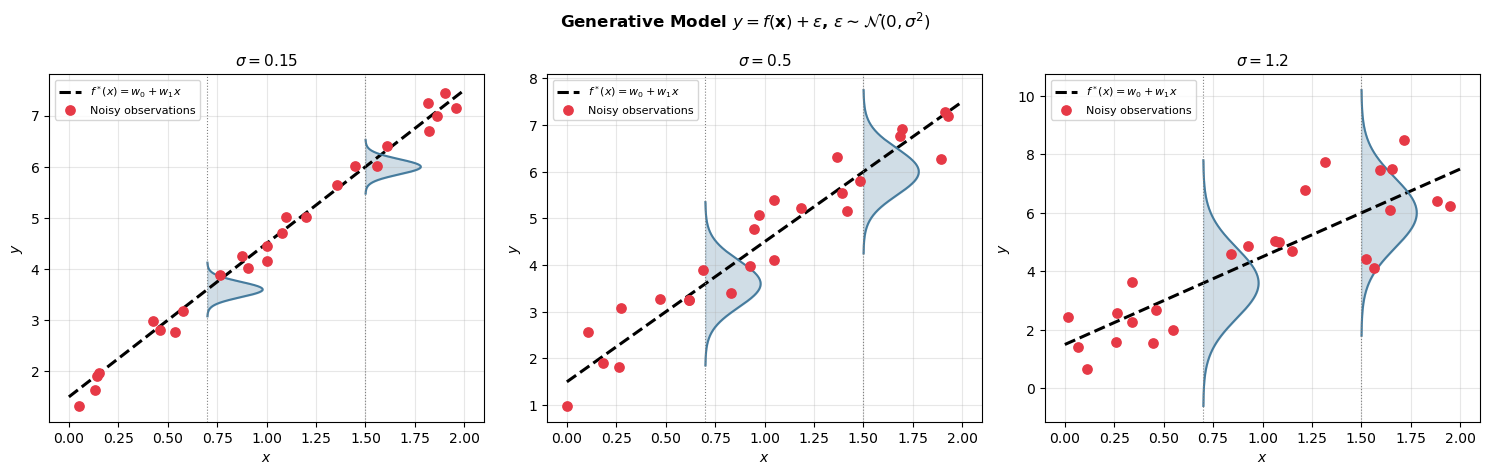

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(7)
w_true = np.array([1.5, 3.0])
x_line = np.linspace(0, 2, 200)
f_line = w_true[0] + w_true[1]*x_line

sigma_values = [0.15, 0.5, 1.2]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, sigma in zip(axes, sigma_values):
    x_tr = np.random.uniform(0, 2, 25)
    y_tr = w_true[0] + w_true[1]*x_tr + np.random.normal(0, sigma, 25)
    ax.plot(x_line, f_line, 'k--', lw=2.2, label=r'$f^*(x) = w_0 + w_1 x$')
    ax.scatter(x_tr, y_tr, s=45, color='#E63946', zorder=5, label='Noisy observations')
    for x0 in [0.7, 1.5]:
        mu = w_true[0] + w_true[1]*x0
        eps_r = np.linspace(mu-3.5*sigma, mu+3.5*sigma, 300)
        pdf   = norm.pdf(eps_r, mu, sigma)
        pdf_s = pdf / pdf.max() * 0.28
        ax.fill_betweenx(eps_r, x0, x0+pdf_s, alpha=0.25, color='#457B9D')
        ax.plot(x0+pdf_s, eps_r, color='#457B9D', lw=1.5)
        ax.axvline(x0, color='gray', lw=0.8, linestyle=':')
    ax.set_title(f'$\\sigma = {sigma}$', fontsize=11)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle(r'Generative Model $y = f(\mathbf{x}) + \epsilon$, $\epsilon \sim \mathcal{N}(0,\sigma^2)$', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 3. The Linear Regression Model and the Augmented Vector Trick

Without a bias, $\hat{y} = \mathbf{w}^T\mathbf{x}$ forces the hyperplane through the origin. We introduce the **Bias** $w_0$ to obtain an affine map:

$$\hat{y} = w_0 + \sum_{j=1}^d w_j x_j$$

### The Augmented Vector Trick

Prepend $x_0=1$ to every input and $w_0$ to the parameter vector:

$$\mathbf{x}_{\text{aug}} = \begin{bmatrix}1 \\ x_1 \\ \vdots \\ x_d\end{bmatrix} \in \mathbb{R}^{d+1}, \qquad \mathbf{w}_{\text{aug}} = \begin{bmatrix}w_0 \\ w_1 \\ \vdots \\ w_d\end{bmatrix} \in \mathbb{R}^{d+1}$$

Model collapses to a single dot product:

$$\boxed{\hat{y} = \mathbf{w}^T\mathbf{x}}$$

The full dataset is stacked in the **Design Matrix** $\mathbf{X} \in \mathbb{R}^{N \times (d+1)}$, with $\hat{\mathbf{y}} = \mathbf{X}\mathbf{w}$.


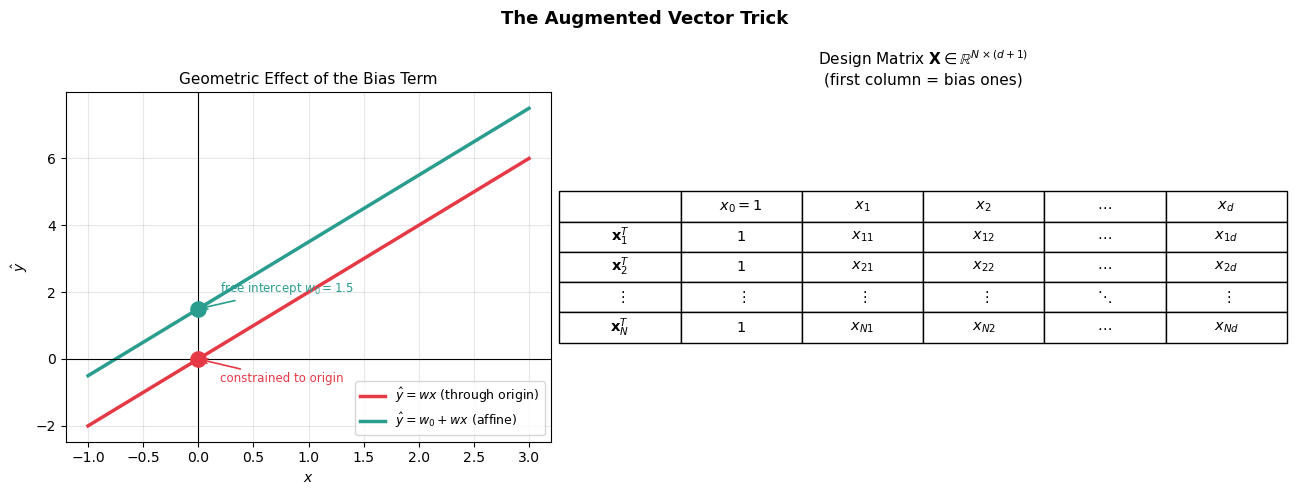

=== Numerical Verification ===
X_aug:
[[ 1.   1.2  0.5]
 [ 1.   2.1 -0.3]
 [ 1.   0.8  1.1]
 [ 1.   3.   0. ]
 [ 1.   1.5 -0.9]]
w = [ 0.5  1.2 -0.8]
y_hat = [1.54 3.26 0.58 4.1  3.02]


In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x1d = np.linspace(-1, 3, 200)
ax  = axes[0]
ax.plot(x1d, 2.0*x1d,       '#E63946', lw=2.5, label=r'$\hat{y}=wx$ (through origin)')
ax.plot(x1d, 1.5+2.0*x1d,  '#2A9D8F', lw=2.5, label=r'$\hat{y}=w_0+wx$ (affine)')
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
ax.scatter([0],[0],   s=120, color='#E63946', zorder=5)
ax.scatter([0],[1.5], s=120, color='#2A9D8F', zorder=5)
ax.annotate('constrained to origin', xy=(0,0),   xytext=(0.2,-0.7), fontsize=8.5, color='#E63946',
            arrowprops=dict(arrowstyle='->', color='#E63946', lw=1.2))
ax.annotate('free intercept $w_0=1.5$', xy=(0,1.5), xytext=(0.2,2.0), fontsize=8.5, color='#2A9D8F',
            arrowprops=dict(arrowstyle='->', color='#2A9D8F', lw=1.2))
ax.set_title('Geometric Effect of the Bias Term', fontsize=11)
ax.set_xlabel('$x$'); ax.set_ylabel(r'$\hat{y}$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax2 = axes[1]; ax2.axis('off')
table_data = [
    ['', '$x_0=1$', '$x_1$', '$x_2$', r'$\cdots$', '$x_d$'],
    [r'$\mathbf{x}_1^T$', '1', '$x_{11}$', '$x_{12}$', r'$\cdots$', '$x_{1d}$'],
    [r'$\mathbf{x}_2^T$', '1', '$x_{21}$', '$x_{22}$', r'$\cdots$', '$x_{2d}$'],
    [r'$\vdots$', r'$\vdots$', r'$\vdots$', r'$\vdots$', r'$\ddots$', r'$\vdots$'],
    [r'$\mathbf{x}_N^T$', '1', '$x_{N1}$', '$x_{N2}$', r'$\cdots$', '$x_{Nd}$'],
]
tbl = ax2.table(cellText=table_data, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10.5); tbl.scale(1.5, 2.0)
ax2.set_title(r'Design Matrix $\mathbf{X} \in \mathbb{R}^{N \times (d+1)}$'
              + '\n(first column = bias ones)', fontsize=11)

plt.suptitle('The Augmented Vector Trick', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('=== Numerical Verification ===')
N, d = 5, 2
X_raw = np.array([[1.2,0.5],[2.1,-0.3],[0.8,1.1],[3.0,0.0],[1.5,-0.9]])
X_aug = np.hstack([np.ones((N,1)), X_raw])
w     = np.array([0.5, 1.2, -0.8])
print(f'X_aug:\n{X_aug}\nw = {w}\ny_hat = {(X_aug@w).round(4)}')


---
## 4. Objective Function: Residual Sum of Squares (RSS)

$$\boxed{L(\mathbf{w}) = \|\mathbf{y}-\mathbf{X}\mathbf{w}\|_2^2 = (\mathbf{y}-\mathbf{X}\mathbf{w})^T(\mathbf{y}-\mathbf{X}\mathbf{w})}$$

### Why the $L_2$ Squared Norm?
1. **Convex, continuous, differentiable everywhere** → global minimum via calculus.
2. **MLE ≡ minimizing RSS** under Gaussian noise (Section 6C).

### The $\frac{1}{2}$ Convention
Scaling by $\frac{1}{2}$ does not shift the $\arg\min$. It cancels with the exponent 2 during differentiation:

$$\frac{d}{dw}\frac{1}{2}(y-wx)^2 = -(y-wx)\cdot x \qquad \text{(no extra constant)}$$


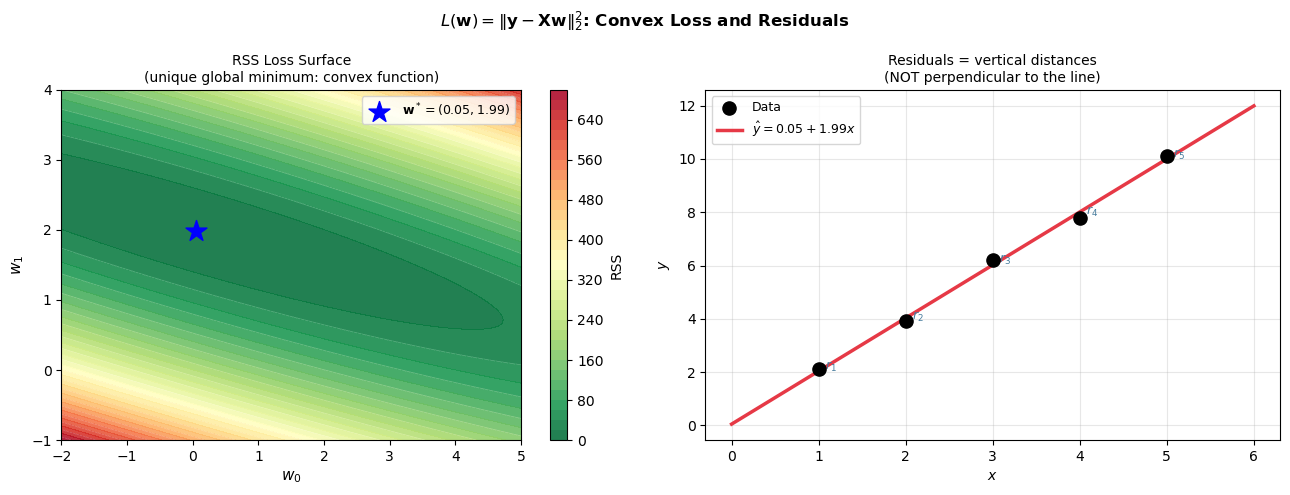

Optimal: w0=0.0500, w1=1.9900  |  Min RSS=0.1070


In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)
x_data = np.array([1., 2., 3., 4., 5.])
y_data = np.array([2.1, 3.9, 6.2, 7.8, 10.1])

w0_r = np.linspace(-2, 5, 120)
w1_r = np.linspace(-1, 4, 120)
W0, W1 = np.meshgrid(w0_r, w1_r)
X_aug  = np.column_stack([np.ones_like(x_data), x_data])
RSS    = np.array([
    np.sum((y_data - W0[i,j] - W1[i,j]*x_data)**2)
    for i in range(120) for j in range(120)
]).reshape(120, 120)
w_opt = np.linalg.lstsq(X_aug, y_data, rcond=None)[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
cp = ax.contourf(W0, W1, RSS, levels=45, cmap='RdYlGn_r', alpha=0.88)
plt.colorbar(cp, ax=ax, label='RSS')
ax.contour(W0, W1, RSS, levels=22, colors='white', linewidths=0.5, alpha=0.35)
ax.scatter(*w_opt, s=250, color='blue', marker='*', zorder=10,
           label=f'$\\mathbf{{w}}^*=({w_opt[0]:.2f},{w_opt[1]:.2f})$')
ax.set_xlabel('$w_0$', fontsize=11); ax.set_ylabel('$w_1$', fontsize=11)
ax.set_title('RSS Loss Surface\n(unique global minimum: convex function)', fontsize=10)
ax.legend(fontsize=9)

ax2 = axes[1]
x_plot = np.linspace(0, 6, 200)
ax2.scatter(x_data, y_data, s=90, color='black', zorder=5, label='Data')
ax2.plot(x_plot, w_opt[0]+w_opt[1]*x_plot, '#E63946', lw=2.5,
         label=f'$\\hat{{y}}={w_opt[0]:.2f}+{w_opt[1]:.2f}x$')
for xi, yi in zip(x_data, y_data):
    yi_hat = w_opt[0]+w_opt[1]*xi
    ax2.plot([xi,xi],[yi,yi_hat], '#457B9D', lw=2, linestyle='--')
    ax2.annotate(f'$r_{int(xi)}$', xy=(xi+0.07,(yi+yi_hat)/2), fontsize=9, color='#457B9D')
ax2.set_xlabel('$x$'); ax2.set_ylabel('$y$')
ax2.set_title('Residuals = vertical distances\n(NOT perpendicular to the line)', fontsize=10)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.suptitle(r'$L(\mathbf{w}) = \|\mathbf{y}-\mathbf{X}\mathbf{w}\|_2^2$: Convex Loss and Residuals', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Optimal: w0={w_opt[0]:.4f}, w1={w_opt[1]:.4f}  |  Min RSS={np.sum((y_data-X_aug@w_opt)**2):.4f}')


---
## 5. From True Risk to ERM — Dimensional Analysis

### True Risk vs. Empirical Risk

$$R(f) = \mathbb{E}_{(\mathbf{x},y)\sim p}[L(y,f(\mathbf{x}))] = \iint L(y,f(\mathbf{x}))\,p(\mathbf{x},y)\,d\mathbf{x}\,dy \quad \text{(uncomputable)}$$

By the Law of Large Numbers:

$$\hat{R}_{\text{emp}}(\mathbf{w}) = \frac{1}{N}\sum_{i=1}^N L(y_i,f(\mathbf{x}_i)) \xrightarrow{N\to\infty} R(f)$$

For squared loss, ERM $\equiv$ minimizing MSE. The $\frac{1}{2}$ factor eliminates the constant from the gradient without shifting the minimizer.

### Dimensional Analysis

| Object | Dimension | Role |
|--------|-----------|------|
| $\mathbf{X}$ | $N \times (d+1)$ | Design matrix |
| $\mathbf{w}$ | $(d+1) \times 1$ | Weight vector |
| $\mathbf{y}$ | $N \times 1$ | Target vector |
| $\mathbf{X}\mathbf{w}$ | $N \times 1$ | Predictions |
| $\mathbf{y}-\mathbf{X}\mathbf{w}$ | $N \times 1$ | Residual vector |
| $\mathbf{X}^T\mathbf{X}$ | $(d+1)\times(d+1)$ | Empirical covariance |
| $\mathbf{X}^T\mathbf{y}$ | $(d+1)\times 1$ | Cross-covariance |
| $L(\mathbf{w})$ | scalar | Loss |


In [6]:
import numpy as np

np.random.seed(1)
N, d = 50, 3
X = np.hstack([np.ones((N,1)), np.random.randn(N,d)])
w_true = np.array([1.0, 2.5, -1.2, 0.8])
y = X @ w_true + np.random.normal(0, 0.5, N)

print('=== Dimensional Analysis ===')
for name, obj in [('X        ', X), ('w        ', w_true), ('y        ', y),
                   ('Xw       ', X@w_true), ('y-Xw     ', y-X@w_true),
                   ('X^T X    ', X.T@X), ('X^T y    ', X.T@y)]:
    print(f'  {name}: shape {obj.shape}')

w_rand = np.random.randn(d+1)
w_opt  = np.linalg.lstsq(X, y, rcond=None)[0]
mse    = lambda w: np.sum((y-X@w)**2)/len(y)
print(f'\nMSE (random w):   {mse(w_rand):.4f}')
print(f'MSE (optimal w*): {mse(w_opt):.6f}')
print(f'True w:  {w_true}')
print(f'Found w*:{w_opt.round(4)}')


=== Dimensional Analysis ===
  X        : shape (50, 4)
  w        : shape (4,)
  y        : shape (50,)
  Xw       : shape (50,)
  y-Xw     : shape (50,)
  X^T X    : shape (4, 4)
  X^T y    : shape (4,)

MSE (random w):   6.1597
MSE (optimal w*): 0.206034
True w:  [ 1.   2.5 -1.2  0.8]
Found w*:[ 1.085   2.6618 -1.0795  0.913 ]


---
## 6. Three Roads to the Optimal Parameters ($\mathbf{w}^*$)

### 6A. Analytical — Full Derivation of the Normal Equations

Expand the loss:

$$L(\mathbf{w}) = \mathbf{y}^T\mathbf{y} - 2\mathbf{w}^T\mathbf{X}^T\mathbf{y} + \mathbf{w}^T\mathbf{X}^T\mathbf{X}\mathbf{w}$$

Gradient ($\nabla_\mathbf{w}\mathbf{b}^T\mathbf{w}=\mathbf{b}$ and $\nabla_\mathbf{w}\mathbf{w}^TA\mathbf{w}=2A\mathbf{w}$ for symmetric $A$):

$$\nabla_\mathbf{w} L = -2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\mathbf{w} = \mathbf{0}$$

$$\implies \underbrace{\mathbf{X}^T\mathbf{X}\,\mathbf{w} = \mathbf{X}^T\mathbf{y}}_{\text{Normal Equations}} \implies \boxed{\mathbf{w}^* = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}}$$

Invertibility requires $\text{rank}(\mathbf{X})=d+1$: columns of $\mathbf{X}$ linearly independent and $N\geq d+1$.

---

### 6B. Geometric — Orthogonal Projection & Hat Matrix

**Data space:** residuals are vertical distances (parallel to $Y$-axis) — not perpendicular to the line.

**Column space $\mathbb{R}^N$:** $\mathbf{y}\notin\text{col}(\mathbf{X})$ in general. The best approximation is the orthogonal projection of $\mathbf{y}$ onto $\text{col}(\mathbf{X})$. The residual is minimized when perpendicular to every column:

$$\mathbf{X}^T(\mathbf{y}-\mathbf{X}\mathbf{w}^*) = \mathbf{0} \quad \text{(recovers the Normal Equations)}$$

The **Hat Matrix** $\mathbf{H}=\mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$:

$$\hat{\mathbf{y}} = \mathbf{H}\mathbf{y}, \qquad \mathbf{r} = (\mathbf{I}-\mathbf{H})\mathbf{y}$$

Properties: **symmetric** ($\mathbf{H}^T=\mathbf{H}$), **idempotent** ($\mathbf{H}^2=\mathbf{H}$), eigenvalues $\in\{0,1\}$, $\text{rank}(\mathbf{H})=d+1$.

---

### 6C. Probabilistic — MLE

Under $y_i\sim\mathcal{N}(\mathbf{w}^T\mathbf{x}_i,\sigma^2)$:

$$\ln L(\mathbf{w}) = \underbrace{-\frac{N}{2}\log(2\pi\sigma^2)}_{\text{const}} - \frac{1}{2\sigma^2}\underbrace{\sum_i(y_i-\mathbf{w}^T\mathbf{x}_i)^2}_{\text{RSS}}$$

$$\mathbf{w}^*_{\text{MLE}} = \arg\max\ln L = \arg\min\text{RSS} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

> All three approaches converge to the **same** closed-form solution. Adding a Gaussian prior on $\mathbf{w}$ in 6C yields MAP estimation — the probabilistic foundation of Ridge regression.


=== Hat Matrix Properties ===
Symmetric:    True
Idempotent:   True
max|X^T r| = 1.07e-13   (must be ~0)
Eigenvalues: 2 ones, 38 zeros


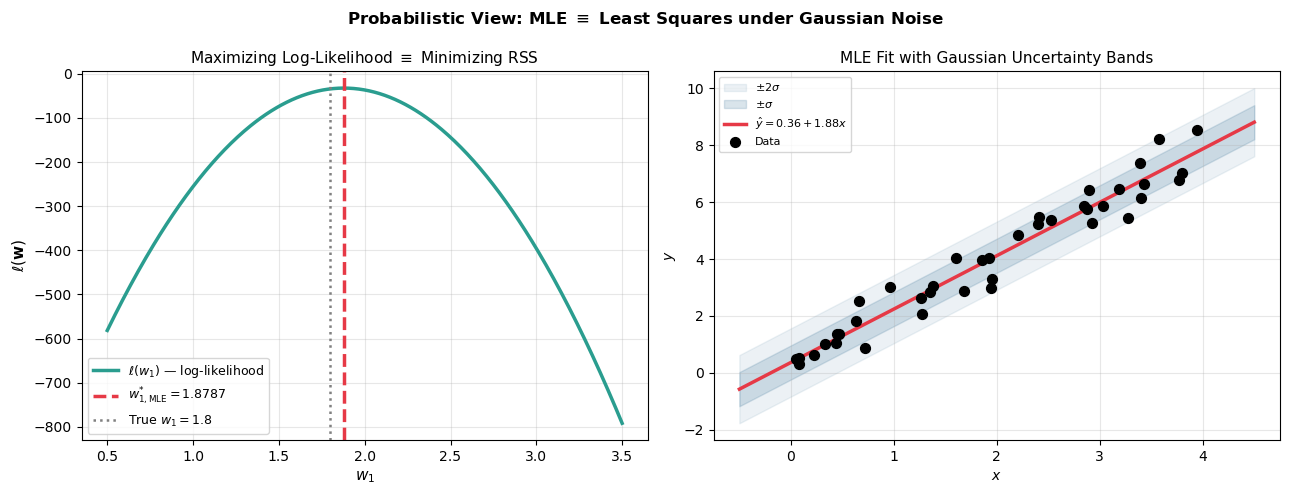

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm as spnorm

np.random.seed(11)
N = 40
x = np.sort(np.random.uniform(0, 4, N))
w_true = np.array([0.5, 1.8])
sigma  = 0.6
y = w_true[0] + w_true[1]*x + np.random.normal(0, sigma, N)

X     = np.column_stack([np.ones(N), x])
w_mle = np.linalg.inv(X.T@X) @ X.T @ y
H     = X @ np.linalg.inv(X.T@X) @ X.T
y_hat = H @ y
r     = y - y_hat

print('=== Hat Matrix Properties ===')
print(f'Symmetric:    {np.allclose(H, H.T)}')
print(f'Idempotent:   {np.allclose(H@H, H)}')
print(f'max|X^T r| = {np.abs(X.T@r).max():.2e}   (must be ~0)')
eigs = np.linalg.eigvalsh(H)
print(f'Eigenvalues: {np.sum(np.isclose(eigs,1.,atol=1e-8))} ones, {np.sum(np.isclose(eigs,0.,atol=1e-8))} zeros')

# Log-likelihood and MLE fit
w1_range = np.linspace(0.5, 3.5, 400)
log_lik  = np.array([
    -N/2*np.log(2*np.pi*sigma**2) - 1/(2*sigma**2)*np.sum((y - w_mle[0] - w1*x)**2)
    for w1 in w1_range
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(w1_range, log_lik, '#2A9D8F', lw=2.5, label=r'$\ell(w_1)$ — log-likelihood')
ax.axvline(w_mle[1], color='#E63946', lw=2.5, linestyle='--',
           label=f'$w_{{1,\\mathrm{{MLE}}}}^{{*}}={w_mle[1]:.4f}$')
ax.axvline(w_true[1], color='gray', lw=1.8, linestyle=':',
           label=f'True $w_1={w_true[1]}$')
ax.set_xlabel('$w_1$', fontsize=11); ax.set_ylabel(r'$\ell(\mathbf{w})$', fontsize=11)
ax.set_title(r'Maximizing Log-Likelihood $\equiv$ Minimizing RSS', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax2 = axes[1]
x_plot = np.linspace(-0.5, 4.5, 300)
y_fit  = w_mle[0] + w_mle[1]*x_plot
ax2.fill_between(x_plot, y_fit-2*sigma, y_fit+2*sigma, alpha=0.10, color='#457B9D', label=r'$\pm2\sigma$')
ax2.fill_between(x_plot, y_fit-sigma,   y_fit+sigma,   alpha=0.20, color='#457B9D', label=r'$\pm\sigma$')
ax2.plot(x_plot, y_fit, '#E63946', lw=2.5, label=f'$\\hat{{y}}={w_mle[0]:.2f}+{w_mle[1]:.2f}x$')
ax2.scatter(x, y, s=50, color='black', zorder=5, label='Data')
ax2.set_xlabel('$x$'); ax2.set_ylabel('$y$')
ax2.set_title('MLE Fit with Gaussian Uncertainty Bands', fontsize=11)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle(r'Probabilistic View: MLE $\equiv$ Least Squares under Gaussian Noise', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 7. Gauss-Markov Theorem: OLS is BLUE

> *Reference: C. R. Rao — Linear Statistical Inference and Its Applications, Ch. 4 [6]*

The **Gauss-Markov Theorem** provides the theoretical bedrock that formally justifies why we use Ordinary Least Squares over any other linear estimator. It states:

> Under the Classical Linear Regression assumptions, the OLS estimator $\mathbf{w}^*=(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ is the **Best Linear Unbiased Estimator (BLUE)**: among all linear unbiased estimators of $\mathbf{w}_{\text{true}}$, it has the minimum variance.

### The Classical Assumptions (Gauss-Markov conditions)

| Assumption | Formal statement |
|------------|------------------|
| **Linearity** | $\mathbf{y} = \mathbf{X}\mathbf{w}_{\text{true}} + \boldsymbol{\epsilon}$ |
| **Zero mean** | $\mathbb{E}[\boldsymbol{\epsilon}] = \mathbf{0}$ |
| **Homoscedasticity** | $\text{Var}(\epsilon_i) = \sigma^2$ (constant for all $i$) |
| **No autocorrelation** | $\text{Cov}(\epsilon_i, \epsilon_j) = 0$ for $i \neq j$ |
| **Full rank** | $\text{rank}(\mathbf{X}) = d+1$ |

**Note:** Normality of $\boldsymbol{\epsilon}$ is *not* required for Gauss-Markov — only for inference (hypothesis testing, confidence intervals).

---

### Proof: Unbiasedness of OLS

Substitute $\mathbf{y} = \mathbf{X}\mathbf{w}_{\text{true}} + \boldsymbol{\epsilon}$:

$$\mathbf{w}^* = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T(\mathbf{X}\mathbf{w}_{\text{true}} + \boldsymbol{\epsilon}) = \mathbf{w}_{\text{true}} + (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\boldsymbol{\epsilon}$$

Taking expectations:

$$\mathbb{E}[\mathbf{w}^*] = \mathbf{w}_{\text{true}} + (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\underbrace{\mathbb{E}[\boldsymbol{\epsilon}]}_{=\mathbf{0}} = \mathbf{w}_{\text{true}}$$

OLS is **unbiased**: on average, it recovers the true parameters exactly.

---

### Proof: Minimum Variance (BLUE)

The covariance matrix of the OLS estimator is:

$$\text{Cov}(\mathbf{w}^*) = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\,\text{Cov}(\boldsymbol{\epsilon})\,\mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}$$

Under homoscedasticity and no autocorrelation: $\text{Cov}(\boldsymbol{\epsilon}) = \sigma^2\mathbf{I}$. So:

$$\boxed{\text{Cov}(\mathbf{w}^*) = \sigma^2(\mathbf{X}^T\mathbf{X})^{-1}}$$

Now consider **any other** linear unbiased estimator $\tilde{\mathbf{w}} = \mathbf{C}\mathbf{y}$ where $\mathbf{C}\mathbf{X}=\mathbf{I}$ (unbiasedness condition). Write $\mathbf{C} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T + \mathbf{D}$ for some matrix $\mathbf{D}$ with $\mathbf{D}\mathbf{X}=\mathbf{0}$. Then:

$$\text{Cov}(\tilde{\mathbf{w}}) = \sigma^2\mathbf{C}\mathbf{C}^T = \sigma^2(\mathbf{X}^T\mathbf{X})^{-1} + \sigma^2\mathbf{D}\mathbf{D}^T$$

Since $\mathbf{D}\mathbf{D}^T$ is positive semi-definite:

$$\text{Cov}(\tilde{\mathbf{w}}) - \text{Cov}(\mathbf{w}^*) = \sigma^2\mathbf{D}\mathbf{D}^T \succeq \mathbf{0}$$

OLS has **minimum variance** among all linear unbiased estimators. $\blacksquare$

---

### When does Gauss-Markov fail?

| Violation | Consequence | Remedy |
|-----------|-------------|--------|
| Heteroscedasticity | OLS still unbiased but no longer min-variance | Weighted Least Squares (WLS) |
| Autocorrelation | OLS still unbiased but no longer min-variance | Generalized LS (GLS) |
| Multicollinearity | $(\mathbf{X}^T\mathbf{X})$ near-singular → huge variance | Ridge regularization |
| Non-linearity | OLS biased | Polynomial / kernel regression |


=== Gauss-Markov: Verifying Unbiasedness and Variance ===
Weight |     True |     E[w*] MC |       Bias |       Var MC |   Var Theory
------------------------------------------------------------------------
  w_0   |   1.5000 |     1.499501 |  -0.000499 |     0.022026 |     0.022575
  w_1   |   2.0000 |     2.008462 |   0.008462 |     0.031445 |     0.031376
  w_2   |  -1.0000 |    -1.007764 |  -0.007764 |     0.022898 |     0.022637


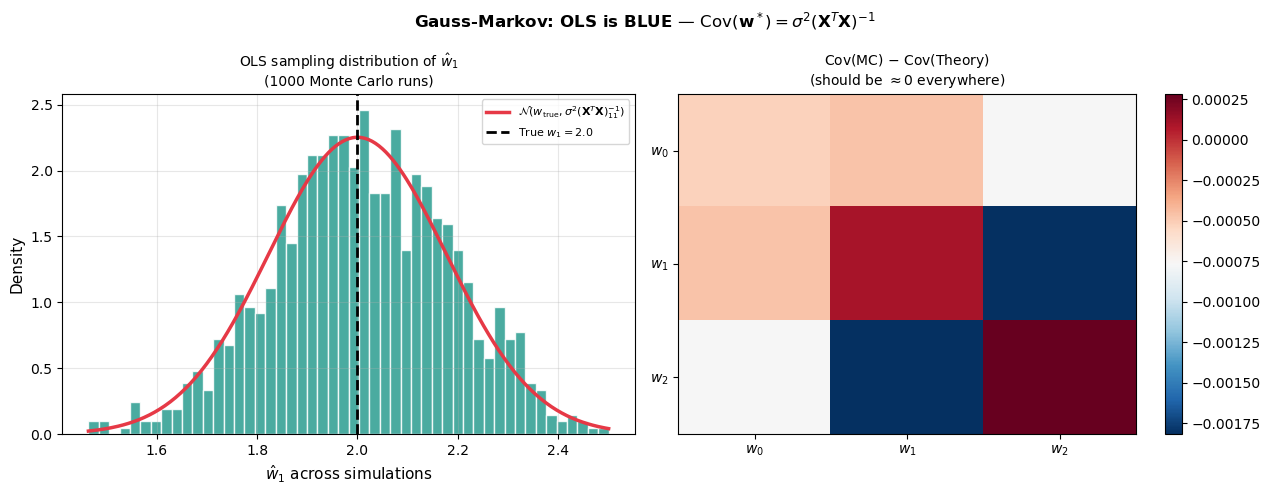

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
N_sim = 1000    # Monte Carlo simulations
N, d  = 30, 2
X_fixed = np.hstack([np.ones((N,1)), np.random.randn(N,d)])
w_true  = np.array([1.5, 2.0, -1.0])
sigma   = 0.8

# Collect OLS estimates over many noise realizations
ols_estimates = []
for _ in range(N_sim):
    eps = np.random.normal(0, sigma, N)
    y   = X_fixed @ w_true + eps
    w_hat = np.linalg.lstsq(X_fixed, y, rcond=None)[0]
    ols_estimates.append(w_hat)

ols_estimates = np.array(ols_estimates)  # (N_sim, d+1)

# Theoretical covariance
Cov_theory = sigma**2 * np.linalg.inv(X_fixed.T @ X_fixed)

print('=== Gauss-Markov: Verifying Unbiasedness and Variance ===')
print(f'{"Weight":>6} | {"True":>8} | {"E[w*] MC":>12} | {"Bias":>10} | {"Var MC":>12} | {"Var Theory":>12}')
print('-'*72)
for j in range(d+1):
    bias     = np.mean(ols_estimates[:,j]) - w_true[j]
    var_mc   = np.var(ols_estimates[:,j])
    var_th   = Cov_theory[j,j]
    print(f'  w_{j}   | {w_true[j]:>8.4f} | {np.mean(ols_estimates[:,j]):>12.6f} | {bias:>10.6f} | {var_mc:>12.6f} | {var_th:>12.6f}')

# Visualize sampling distribution of w1
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(ols_estimates[:,1], bins=50, color='#2A9D8F', edgecolor='white', alpha=0.85, density=True)
from scipy.stats import norm as spnorm
xs = np.linspace(ols_estimates[:,1].min(), ols_estimates[:,1].max(), 300)
ax.plot(xs, spnorm.pdf(xs, w_true[1], np.sqrt(Cov_theory[1,1])), '#E63946', lw=2.5,
        label=r'$\mathcal{N}(w_{\mathrm{true}}, \sigma^2(\mathbf{X}^T\mathbf{X})^{-1}_{11})$')
ax.axvline(w_true[1], color='black', lw=2, linestyle='--', label=f'True $w_1={w_true[1]}$')
ax.set_xlabel('$\\hat{w}_1$ across simulations', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'OLS sampling distribution of $\\hat{{w}}_1$\n({N_sim} Monte Carlo runs)', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Covariance matrix comparison
ax2 = axes[1]
Cov_mc = np.cov(ols_estimates.T)
im = ax2.imshow(Cov_mc - Cov_theory, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax2)
ax2.set_title('Cov(MC) $-$ Cov(Theory)\n(should be $\\approx 0$ everywhere)', fontsize=10)
ax2.set_xticks([0,1,2]); ax2.set_yticks([0,1,2])
ax2.set_xticklabels(['$w_0$','$w_1$','$w_2$'])
ax2.set_yticklabels(['$w_0$','$w_1$','$w_2$'])

plt.suptitle(r'Gauss-Markov: OLS is BLUE — $\text{Cov}(\mathbf{w}^*) = \sigma^2(\mathbf{X}^T\mathbf{X})^{-1}$', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 8. Iterative Optimization: Gradient Descent

Inverting $\mathbf{X}^T\mathbf{X}$ costs $\mathcal{O}(d^3)$. For large $d$ (NLP, genomics), this is prohibitive.

### Update Rule

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta\,\nabla_\mathbf{w} L(\mathbf{w}^{(t)})$$

For $L(\mathbf{w}) = \frac{1}{2N}\|\mathbf{X}\mathbf{w}-\mathbf{y}\|_2^2$:

$$\boxed{\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \frac{\eta}{N}\,\mathbf{X}^T(\mathbf{X}\mathbf{w}^{(t)}-\mathbf{y})}$$

For **Ridge**: $\nabla_\mathbf{w} L_{\text{Ridge}} = \frac{1}{N}\mathbf{X}^T(\mathbf{X}\mathbf{w}-\mathbf{y}) + \lambda\mathbf{w}$

Since RSS is **strictly convex**, any small enough $\eta$ guarantees convergence to the global minimum — the same solution as the Normal Equations.


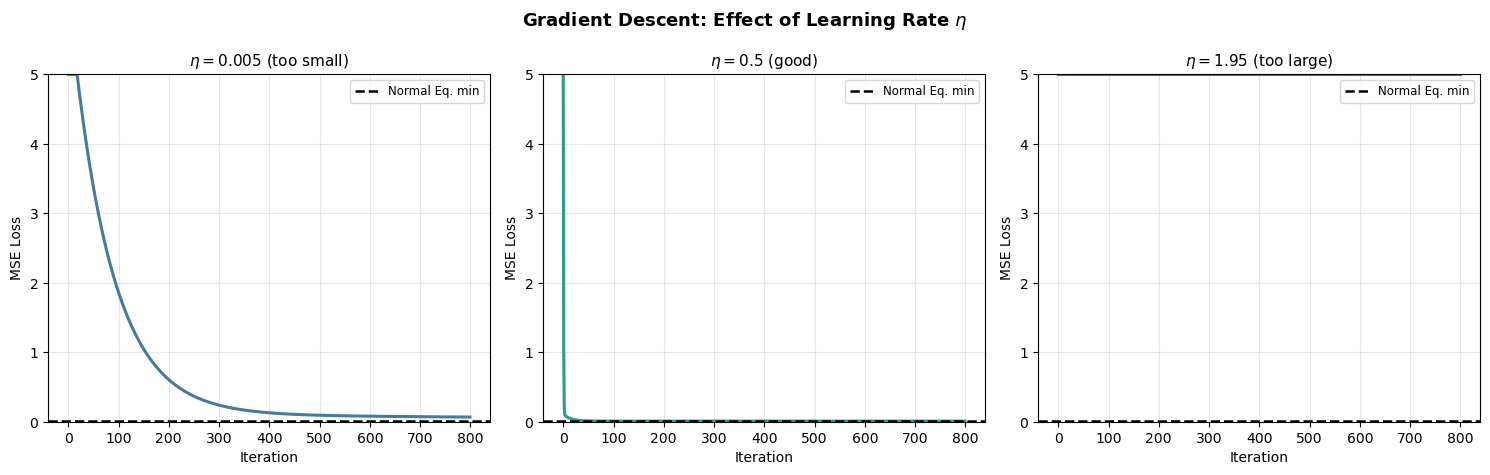

=== GD Convergence (eta=0.5) ===
  Iter |         w0 |         w1 |          MSE
----------------------------------------------
     0 |   1.705190 |   0.930149 |   6.20076883
    20 |   2.391950 |   2.220183 |   0.03321265
   100 |   2.052407 |   2.891225 |   0.00914978
   300 |   2.032279 |   2.931004 |   0.00907408
   599 |   2.032264 |   2.931034 |   0.00907408
Normal Eq: w0=2.032264, w1=2.931034
GD final:  w0=2.032264, w1=2.931034
Converged: True


In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
N = 100
X_raw = np.random.rand(N, 1)
y     = 3.0*X_raw.squeeze() + 2.0 + np.random.normal(0, 0.15, N)
X     = np.hstack([np.ones((N,1)), X_raw])

def gradient_descent(X, y, lr, n_iter=800):
    w = np.zeros(X.shape[1])
    losses, ws = [], []
    for _ in range(n_iter):
        r    = X@w - y
        loss = (1/(2*len(y)))*(r@r)
        w    = w - lr*(1/len(y))*(X.T@r)
        losses.append(loss); ws.append(w.copy())
    return np.array(ws), np.array(losses)

w_ne     = np.linalg.inv(X.T@X) @ X.T @ y
min_loss = (1/(2*N))*np.sum((X@w_ne-y)**2)

lrs    = [0.005, 0.5, 1.95]
labels = [r'$\eta=0.005$ (too small)', r'$\eta=0.5$ (good)', r'$\eta=1.95$ (too large)']
colors_lr = ['#457B9D', '#2A9D8F', '#E63946']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for lr, label, color, ax in zip(lrs, labels, colors_lr, axes):
    _, losses = gradient_descent(X, y, lr)
    ax.plot(np.clip(losses, 0, 5), color=color, lw=2.2)
    ax.axhline(min_loss, color='black', lw=1.8, linestyle='--', label='Normal Eq. min')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Iteration'); ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3); ax.set_ylim(0, 5)

plt.suptitle(r'Gradient Descent: Effect of Learning Rate $\eta$', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

ws_good, losses_good = gradient_descent(X, y, lr=0.5, n_iter=600)
w_final = ws_good[-1]
print('=== GD Convergence (eta=0.5) ===')
print(f'{"Iter":>6} | {"w0":>10} | {"w1":>10} | {"MSE":>12}')
print('-'*46)
for t in [0, 20, 100, 300, 599]:
    print(f'{t:>6} | {ws_good[t,0]:>10.6f} | {ws_good[t,1]:>10.6f} | {losses_good[t]:>12.8f}')
print(f'Normal Eq: w0={w_ne[0]:.6f}, w1={w_ne[1]:.6f}')
print(f'GD final:  w0={w_final[0]:.6f}, w1={w_final[1]:.6f}')
print(f'Converged: {np.allclose(w_final, w_ne, atol=1e-3)}')


---
## 9. Polynomial Regression & the Vandermonde Matrix

When data is nonlinear, $\hat{y}=w_0+w_1x$ underfits. We add polynomial terms:

$$y = w_0 + w_1x + w_2x^2 + \dots + w_dx^d + \epsilon$$

**Linearity in parameters:** nonlinear in $x$, but strictly linear in $\mathbf{w}$ — Normal Equations still apply.

### The Vandermonde Matrix

Feature map $\phi(x) = [1,x,x^2,\ldots,x^d]$ applied to all $n$ samples:

$$\mathbf{\Phi} = \begin{bmatrix}1 & x_1 & x_1^2 & \cdots & x_1^d \\ \vdots & & & \ddots & \vdots \\ 1 & x_n & x_n^2 & \cdots & x_n^d\end{bmatrix} \in \mathbb{R}^{n\times(d+1)}, \qquad \mathbf{w}^* = (\mathbf{\Phi}^T\mathbf{\Phi})^{-1}\mathbf{\Phi}^T\mathbf{y}$$

> As $d$ grows, the condition number of $\mathbf{\Phi}$ grows **exponentially**, making direct inversion numerically unstable — one key motivation for Ridge regularization.


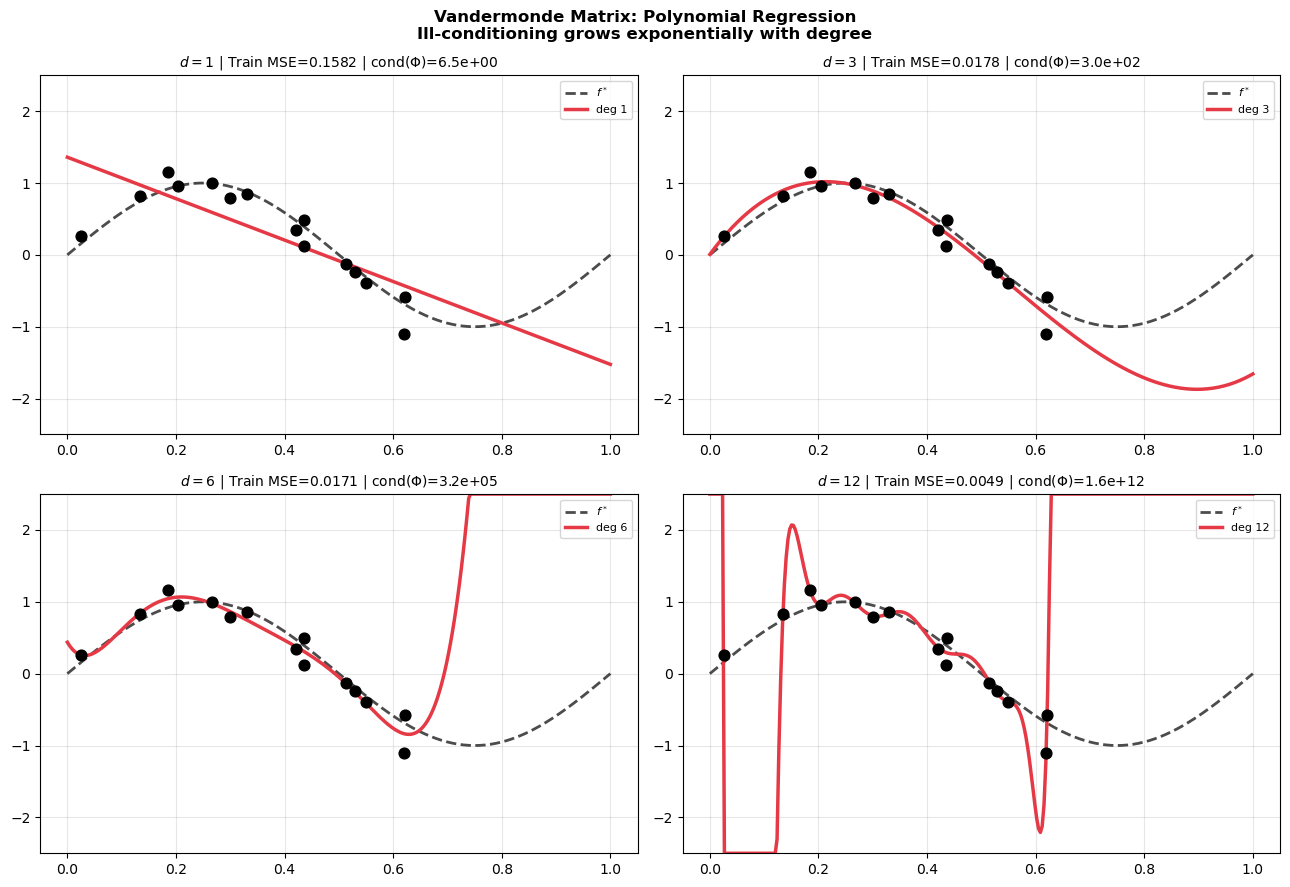

  Degree |       cond(Phi) |    log10
--------------------------------------
       1 |        6.47e+00 |     0.81
       2 |        4.41e+01 |     1.64
       3 |        2.99e+02 |     2.48
       4 |        2.62e+03 |     3.42
       5 |        2.59e+04 |     4.41
       6 |        3.25e+05 |     5.51
       7 |        4.04e+06 |     6.61
       8 |        4.98e+07 |     7.70
       9 |        8.01e+08 |     8.90
      10 |        6.98e+09 |     9.84
      11 |        9.63e+10 |    10.98
      12 |        1.62e+12 |    12.21
      13 |        2.49e+13 |    13.40
      14 |        3.49e+16 |    16.54
      15 |        1.05e+16 |    16.02


In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2)
f_true  = lambda x: np.sin(2*np.pi*x)
n       = 15
x_train = np.sort(np.random.uniform(0, 1, n))
y_train = f_true(x_train) + np.random.normal(0, 0.2, n)
x_plot  = np.linspace(0, 1, 300)

def vandermonde(x, d):
    return np.column_stack([x**j for j in range(d+1)])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, d in zip(axes.flat, [1, 3, 6, 12]):
    Phi_tr = vandermonde(x_train, d)
    w      = np.linalg.lstsq(Phi_tr, y_train, rcond=None)[0]
    mse_tr = np.mean((y_train - Phi_tr@w)**2)
    cond   = np.linalg.cond(Phi_tr)
    ax.plot(x_plot, f_true(x_plot), 'k--', lw=2, alpha=0.7, label=r'$f^*$')
    ax.plot(x_plot, np.clip(vandermonde(x_plot,d)@w, -2.5, 2.5), '#E63946', lw=2.5, label=f'deg {d}')
    ax.scatter(x_train, y_train, s=60, color='black', zorder=5)
    ax.set_xlim(-0.05,1.05); ax.set_ylim(-2.5,2.5)
    ax.set_title(f'$d={d}$ | Train MSE={mse_tr:.4f} | cond($\\Phi$)={cond:.1e}', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Vandermonde Matrix: Polynomial Regression\nIll-conditioning grows exponentially with degree', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'{"Degree":>8} | {"cond(Phi)":>15} | {"log10":>8}')
print('-'*38)
for d in range(1, 16):
    c = np.linalg.cond(vandermonde(x_train, d))
    print(f'{d:>8} | {c:>15.2e} | {np.log10(max(c,1e-20)):>8.2f}')


---
## 10. Overfitting Diagnostics & Bias-Variance Trade-off

### Bias-Variance Decomposition

$$\mathbb{E}_S[R(h_S)] = \underbrace{\sigma^2}_{\text{Noise}} + \underbrace{\text{Bias}^2}_{\text{Approx. error}} + \underbrace{\text{Var}}_{\text{Estim. error}}$$

| Component | Source | Reduced by |
|-----------|--------|------------|
| Noise $\sigma^2$ | Data-generating process | Nothing (irreducible) |
| Bias | $\mathcal{H}$ too small | Richer model |
| Variance | Finite sample + high capacity | More data, regularization |

### Train vs. Validation Loss

When $d\geq n-1$, the polynomial interpolates every training point exactly (**Runge's phenomenon**) → $J_{\text{train}}\to 0$, $J_{\text{val}}\to\infty$.


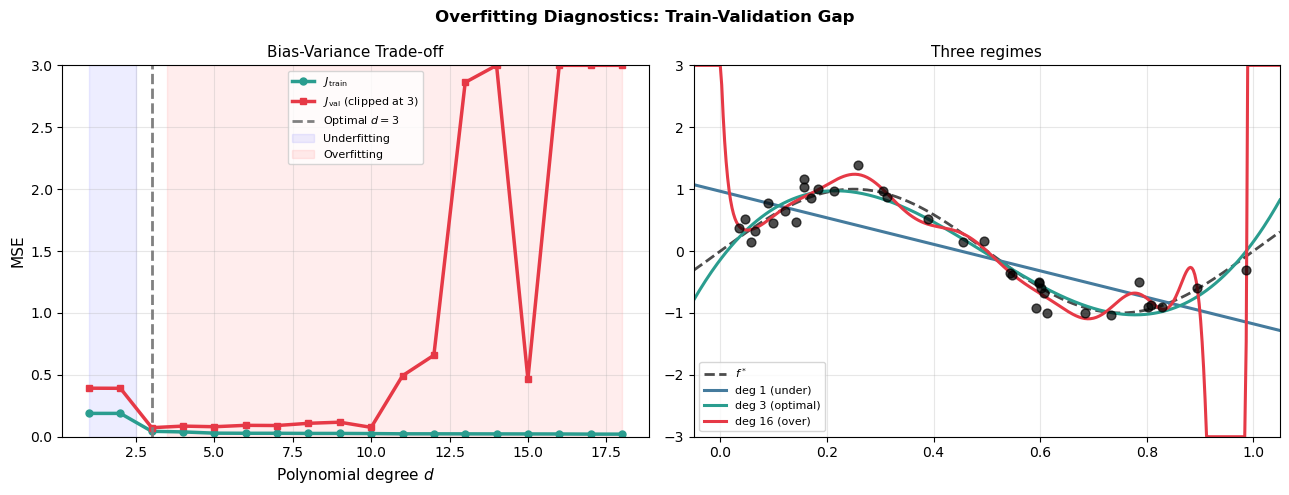

Optimal degree: d = 3


In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
f_true = lambda x: np.sin(2*np.pi*x)
N_tot  = 70
x_all  = np.sort(np.random.uniform(0,1,N_tot))
y_all  = f_true(x_all) + np.random.normal(0, 0.25, N_tot)
idx_tr = np.random.choice(N_tot, 35, replace=False)
idx_vl = np.setdiff1d(np.arange(N_tot), idx_tr)
x_tr, y_tr = x_all[idx_tr], y_all[idx_tr]
x_vl, y_vl = x_all[idx_vl], y_all[idx_vl]

def vandermonde(x, d):
    return np.column_stack([x**j for j in range(d+1)])

max_deg = 18
tr_mses, vl_mses = [], []
for d in range(1, max_deg+1):
    w = np.linalg.lstsq(vandermonde(x_tr,d), y_tr, rcond=None)[0]
    tr_mses.append(np.mean((y_tr - vandermonde(x_tr,d)@w)**2))
    vl_mses.append(np.mean((y_vl - vandermonde(x_vl,d)@w)**2))

degrees = np.arange(1, max_deg+1)
vl_clip = np.clip(vl_mses, 0, 3.0)
best_d  = degrees[np.argmin(vl_clip)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(degrees, tr_mses, '#2A9D8F', lw=2.5, marker='o', ms=5, label=r'$J_{\text{train}}$')
ax.plot(degrees, vl_clip, '#E63946', lw=2.5, marker='s', ms=5, label=r'$J_{\text{val}}$ (clipped at 3)')
ax.axvline(best_d, color='gray', lw=2, linestyle='--', label=f'Optimal $d={best_d}$')
ax.fill_betweenx([0,3], 1, best_d-.5, alpha=0.07, color='blue', label='Underfitting')
ax.fill_betweenx([0,3], best_d+.5, max_deg, alpha=0.07, color='red', label='Overfitting')
ax.set_xlabel('Polynomial degree $d$', fontsize=11); ax.set_ylabel('MSE', fontsize=11)
ax.set_title('Bias-Variance Trade-off', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(0,3)

ax2 = axes[1]
x_plot = np.linspace(-0.05, 1.05, 400)
ax2.plot(x_plot, f_true(x_plot), 'k--', lw=2, alpha=0.7, label=r'$f^*$')
ax2.scatter(x_tr, y_tr, s=40, color='black', zorder=5, alpha=0.7)
for d, c, lbl in zip([1, best_d, 16], ['#457B9D','#2A9D8F','#E63946'],
                     [f'deg 1 (under)', f'deg {best_d} (optimal)', 'deg 16 (over)']):
    w = np.linalg.lstsq(vandermonde(x_tr,d), y_tr, rcond=None)[0]
    ax2.plot(x_plot, np.clip(vandermonde(x_plot,d)@w,-3,3), color=c, lw=2.2, label=lbl)
ax2.set_xlim(-0.05,1.05); ax2.set_ylim(-3,3)
ax2.set_title('Three regimes', fontsize=11)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle('Overfitting Diagnostics: Train-Validation Gap', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Optimal degree: d = {best_d}')


---
## 11. Ridge Regularization ($L_2$): Spectral Analysis

$$J(\mathbf{w}) = \frac{1}{2}(\mathbf{X}\mathbf{w}-\mathbf{y})^T(\mathbf{X}\mathbf{w}-\mathbf{y}) + \frac{\lambda}{2}\|\mathbf{w}\|_2^2$$

Setting $\nabla_\mathbf{w} J=\mathbf{0}$:

$$\boxed{\mathbf{w}_{\text{Ridge}} = (\mathbf{X}^T\mathbf{X}+\lambda\mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}}$$

**Isotropy:** The $L_2$ constraint $\|\mathbf{w}\|_2^2\leq t$ is a hypersphere — isotropic, shrinks all weights uniformly. Unlike Lasso ($L_1$ diamond) which enforces sparsity.

### Spectral Analysis

$\mathbf{X}^T\mathbf{X}=\mathbf{U}\mathbf{\Sigma}\mathbf{U}^T$ (Spectral Theorem). Adding $\lambda\mathbf{I}=\lambda\mathbf{U}\mathbf{U}^T$:

$$\mathbf{X}^T\mathbf{X}+\lambda\mathbf{I} = \mathbf{U}(\mathbf{\Sigma}+\lambda\mathbf{I})\mathbf{U}^T$$

Every eigenvalue shifts: $\sigma_i^2 \to \sigma_i^2+\lambda>0$ → **always invertible**, condition number dramatically reduced.


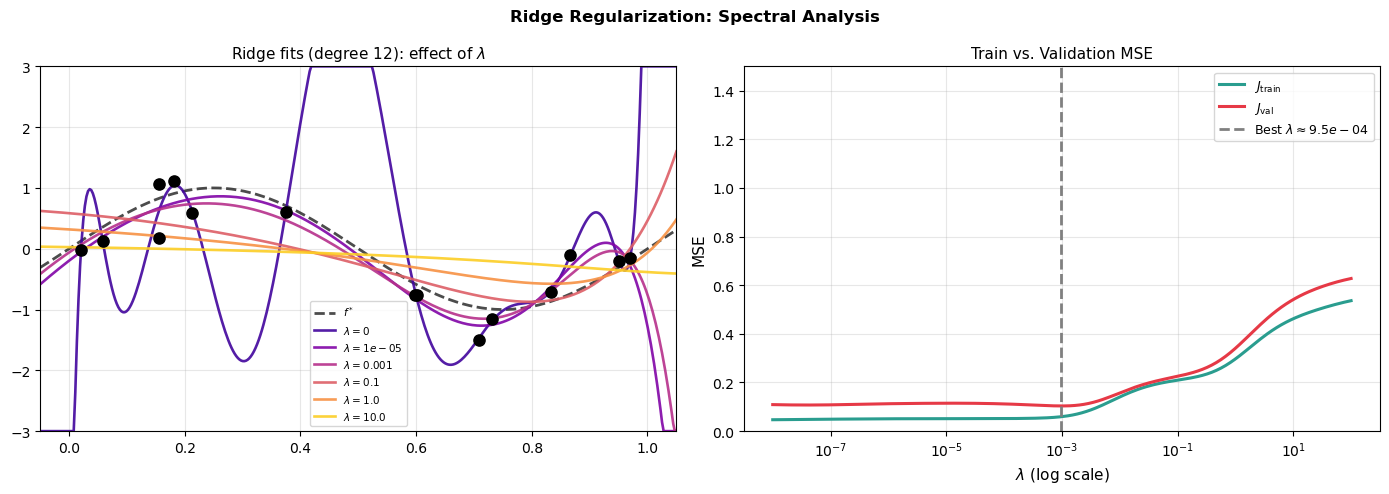

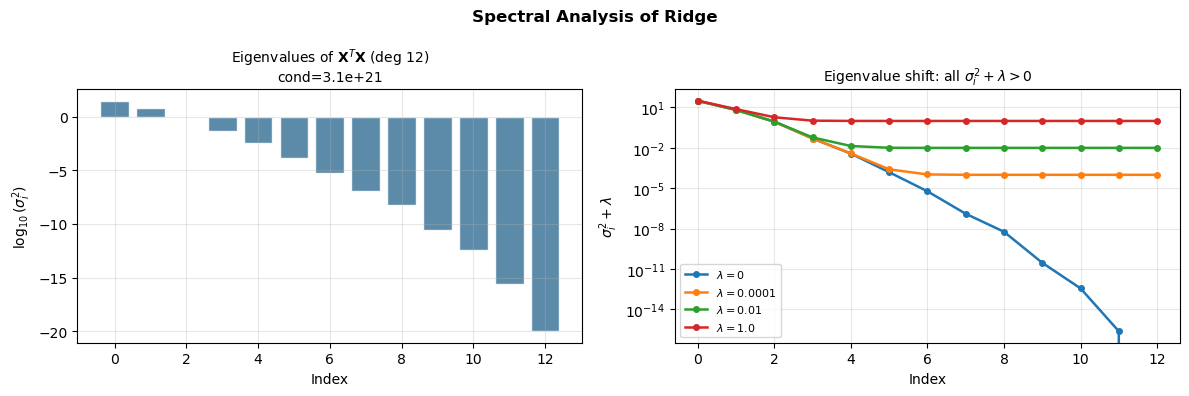

In [12]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
f_true = lambda x: np.sin(2*np.pi*x)
n_tr   = 15
x_tr   = np.sort(np.random.uniform(0,1,n_tr))
y_tr   = f_true(x_tr) + np.random.normal(0, 0.25, n_tr)
x_val  = np.sort(np.random.uniform(0,1,60))
y_val  = f_true(x_val) + np.random.normal(0, 0.25, 60)
x_plot = np.linspace(-0.05,1.05,400)
DEG    = 12

def vdm(x, d): return np.column_stack([x**j for j in range(d+1)])

Phi_tr = vdm(x_tr, DEG); Phi_vl = vdm(x_val, DEG); Phi_pl = vdm(x_plot, DEG)

lambdas = [0, 1e-5, 1e-3, 1e-1, 1.0, 10.0]
colors_r = plt.cm.plasma(np.linspace(0.1, 0.9, len(lambdas)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(x_plot, f_true(x_plot), 'k--', lw=2, alpha=0.7, label=r'$f^*$')
ax.scatter(x_tr, y_tr, s=65, color='black', zorder=5)
for lam, color in zip(lambdas, colors_r):
    A = Phi_tr.T@Phi_tr + lam*np.eye(DEG+1)
    w = np.linalg.solve(A, Phi_tr.T@y_tr)
    ax.plot(x_plot, np.clip(Phi_pl@w,-3,3), color=color, lw=1.9,
            label=f'$\\lambda={lam}$', alpha=0.9)
ax.set_xlim(-0.05,1.05); ax.set_ylim(-3,3)
ax.set_title(f'Ridge fits (degree {DEG}): effect of $\\lambda$', fontsize=11)
ax.legend(fontsize=7.5); ax.grid(True, alpha=0.3)

ax2 = axes[1]
lam_range = np.logspace(-8, 2, 250)
tr_m, vl_m = [], []
for lam in lam_range:
    w = np.linalg.solve(Phi_tr.T@Phi_tr+lam*np.eye(DEG+1), Phi_tr.T@y_tr)
    tr_m.append(np.mean((y_tr - Phi_tr@w)**2))
    vl_m.append(np.mean((y_val - Phi_vl@w)**2))
best_lam = lam_range[np.argmin(np.clip(vl_m,0,1.5))]
ax2.semilogx(lam_range, tr_m, '#2A9D8F', lw=2.2, label=r'$J_{\text{train}}$')
ax2.semilogx(lam_range, np.clip(vl_m,0,1.5), '#E63946', lw=2.2, label=r'$J_{\text{val}}$')
ax2.axvline(best_lam, color='gray', lw=2, linestyle='--', label=f'Best $\\lambda\\approx{best_lam:.1e}$')
ax2.set_xlabel(r'$\lambda$ (log scale)', fontsize=11); ax2.set_ylabel('MSE', fontsize=11)
ax2.set_title('Train vs. Validation MSE', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_ylim(0,1.5)

plt.suptitle('Ridge Regularization: Spectral Analysis', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

XtX = Phi_tr.T@Phi_tr
eigs = np.sort(np.linalg.eigvalsh(XtX))[::-1]
fig2, axes2 = plt.subplots(1,2,figsize=(12,4))
axes2[0].bar(range(len(eigs)), np.log10(np.maximum(eigs,1e-20)), color='#457B9D', edgecolor='white', alpha=0.88)
axes2[0].set_title(f'Eigenvalues of $\\mathbf{{X}}^T\\mathbf{{X}}$ (deg {DEG})\ncond={eigs[0]/max(eigs[-1],1e-20):.1e}', fontsize=10)
axes2[0].set_xlabel('Index'); axes2[0].set_ylabel(r'$\log_{10}(\sigma_i^2)$'); axes2[0].grid(True, alpha=0.3)
for lam in [0, 1e-4, 1e-2, 1.0]:
    axes2[1].semilogy(range(len(eigs)), eigs+lam, marker='o', ms=4, lw=1.8, label=f'$\\lambda={lam}$')
axes2[1].set_title(r'Eigenvalue shift: all $\sigma_i^2+\lambda>0$', fontsize=10)
axes2[1].set_xlabel('Index'); axes2[1].set_ylabel(r'$\sigma_i^2+\lambda$'); axes2[1].legend(fontsize=8); axes2[1].grid(True, alpha=0.3)
plt.suptitle('Spectral Analysis of Ridge', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 12. Expected Value of the Ridge Estimator: A Spectral Perspective

With $\mathbf{y}=\mathbf{X}\mathbf{w}_{\text{true}}+\boldsymbol{\epsilon}$, $\mathbb{E}[\boldsymbol{\epsilon}]=\mathbf{0}$:

$$\mathbb{E}[\mathbf{w}_{\text{Ridge}}] = (\mathbf{X}^T\mathbf{X}+\lambda\mathbf{I})^{-1}\mathbf{X}^T\mathbf{X}\,\mathbf{w}_{\text{true}}$$

Using $\mathbf{X}^T\mathbf{X}=\mathbf{U}\mathbf{\Sigma}\mathbf{U}^T$ and $\mathbf{U}^T\mathbf{U}=\mathbf{I}$:

$$\boxed{\mathbb{E}[\mathbf{w}_{\text{Ridge}}] = \mathbf{U}\operatorname{diag}\!\left(\frac{\sigma_1^2}{\sigma_1^2+\lambda},\ldots,\frac{\sigma_d^2}{\sigma_d^2+\lambda}\right)\mathbf{U}^T\,\mathbf{w}_{\text{true}}}$$

* **Bias:** factor $\frac{\sigma_j^2}{\sigma_j^2+\lambda}<1$ for all $\lambda>0$ → $\mathbb{E}[\mathbf{w}_{\text{Ridge}}]\neq\mathbf{w}_{\text{true}}$
* **Stability:** if $\sigma_j^2\to 0$, OLS explodes; Ridge keeps denominator bounded
* **Limits:** $\lambda\to 0$ → OLS; $\lambda\to\infty$ → $\mathbf{w}\to\mathbf{0}$


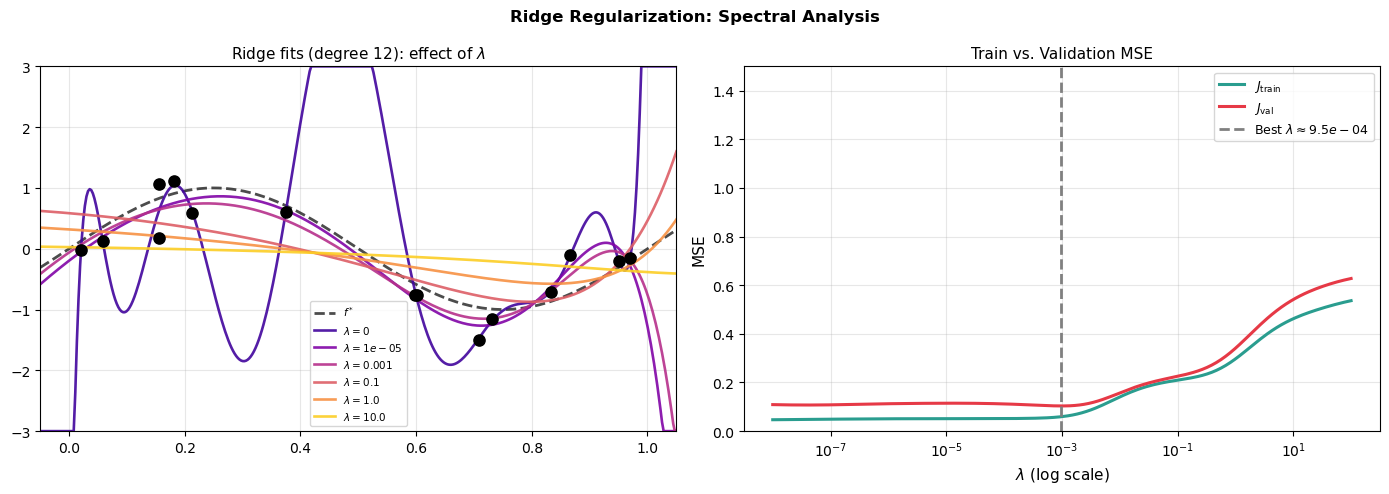

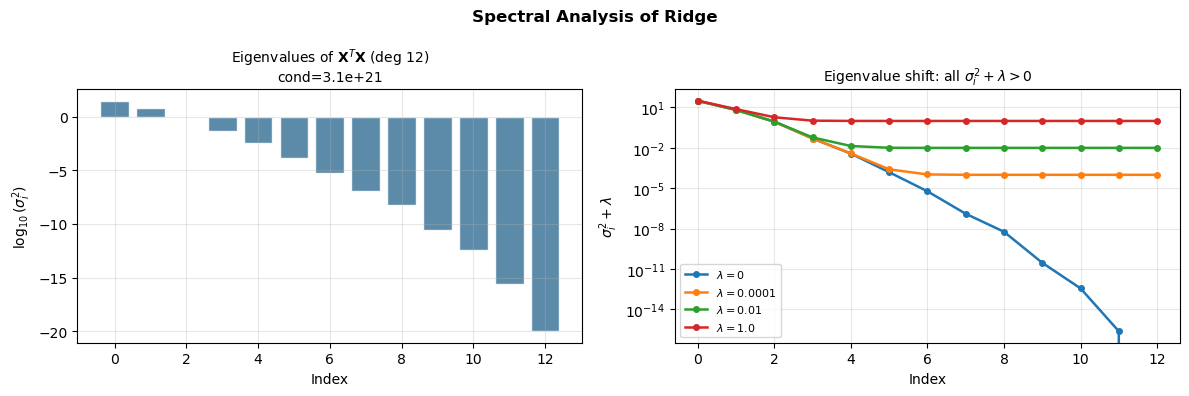

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
f_true = lambda x: np.sin(2*np.pi*x)
n_tr   = 15
x_tr   = np.sort(np.random.uniform(0,1,n_tr))
y_tr   = f_true(x_tr) + np.random.normal(0, 0.25, n_tr)
x_val  = np.sort(np.random.uniform(0,1,60))
y_val  = f_true(x_val) + np.random.normal(0, 0.25, 60)
x_plot = np.linspace(-0.05,1.05,400)
DEG    = 12

def vdm(x, d): return np.column_stack([x**j for j in range(d+1)])

Phi_tr = vdm(x_tr, DEG); Phi_vl = vdm(x_val, DEG); Phi_pl = vdm(x_plot, DEG)

lambdas = [0, 1e-5, 1e-3, 1e-1, 1.0, 10.0]
colors_r = plt.cm.plasma(np.linspace(0.1, 0.9, len(lambdas)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(x_plot, f_true(x_plot), 'k--', lw=2, alpha=0.7, label=r'$f^*$')
ax.scatter(x_tr, y_tr, s=65, color='black', zorder=5)
for lam, color in zip(lambdas, colors_r):
    A = Phi_tr.T@Phi_tr + lam*np.eye(DEG+1)
    w = np.linalg.solve(A, Phi_tr.T@y_tr)
    ax.plot(x_plot, np.clip(Phi_pl@w,-3,3), color=color, lw=1.9,
            label=f'$\\lambda={lam}$', alpha=0.9)
ax.set_xlim(-0.05,1.05); ax.set_ylim(-3,3)
ax.set_title(f'Ridge fits (degree {DEG}): effect of $\\lambda$', fontsize=11)
ax.legend(fontsize=7.5); ax.grid(True, alpha=0.3)

ax2 = axes[1]
lam_range = np.logspace(-8, 2, 250)
tr_m, vl_m = [], []
for lam in lam_range:
    w = np.linalg.solve(Phi_tr.T@Phi_tr+lam*np.eye(DEG+1), Phi_tr.T@y_tr)
    tr_m.append(np.mean((y_tr - Phi_tr@w)**2))
    vl_m.append(np.mean((y_val - Phi_vl@w)**2))
best_lam = lam_range[np.argmin(np.clip(vl_m,0,1.5))]
ax2.semilogx(lam_range, tr_m, '#2A9D8F', lw=2.2, label=r'$J_{\text{train}}$')
ax2.semilogx(lam_range, np.clip(vl_m,0,1.5), '#E63946', lw=2.2, label=r'$J_{\text{val}}$')
ax2.axvline(best_lam, color='gray', lw=2, linestyle='--', label=f'Best $\\lambda\\approx{best_lam:.1e}$')
ax2.set_xlabel(r'$\lambda$ (log scale)', fontsize=11); ax2.set_ylabel('MSE', fontsize=11)
ax2.set_title('Train vs. Validation MSE', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_ylim(0,1.5)

plt.suptitle('Ridge Regularization: Spectral Analysis', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

XtX = Phi_tr.T@Phi_tr
eigs = np.sort(np.linalg.eigvalsh(XtX))[::-1]
fig2, axes2 = plt.subplots(1,2,figsize=(12,4))
axes2[0].bar(range(len(eigs)), np.log10(np.maximum(eigs,1e-20)), color='#457B9D', edgecolor='white', alpha=0.88)
axes2[0].set_title(f'Eigenvalues of $\\mathbf{{X}}^T\\mathbf{{X}}$ (deg {DEG})\ncond={eigs[0]/max(eigs[-1],1e-20):.1e}', fontsize=10)
axes2[0].set_xlabel('Index'); axes2[0].set_ylabel(r'$\log_{10}(\sigma_i^2)$'); axes2[0].grid(True, alpha=0.3)
for lam in [0, 1e-4, 1e-2, 1.0]:
    axes2[1].semilogy(range(len(eigs)), eigs+lam, marker='o', ms=4, lw=1.8, label=f'$\\lambda={lam}$')
axes2[1].set_title(r'Eigenvalue shift: all $\sigma_i^2+\lambda>0$', fontsize=10)
axes2[1].set_xlabel('Index'); axes2[1].set_ylabel(r'$\sigma_i^2+\lambda$'); axes2[1].legend(fontsize=8); axes2[1].grid(True, alpha=0.3)
plt.suptitle('Spectral Analysis of Ridge', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


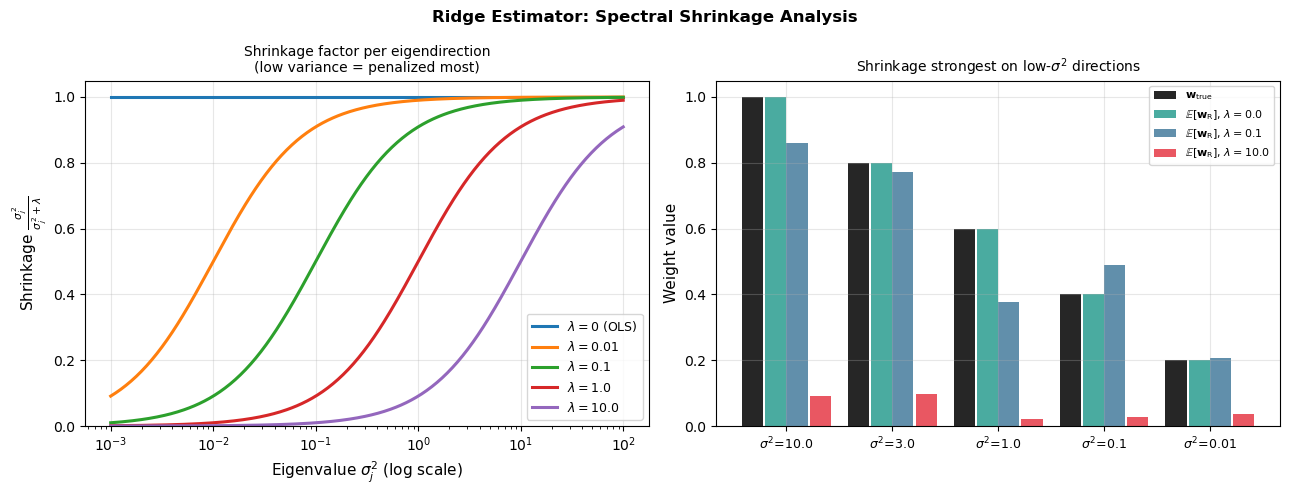

In [14]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
sigma2_vals  = np.logspace(-3, 2, 400)
lambdas_plot = [0.0, 0.01, 0.1, 1.0, 10.0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for lam in lambdas_plot:
    shrink = sigma2_vals / (sigma2_vals + lam)
    lbl = f'$\\lambda={lam}$' if lam > 0 else r'$\lambda=0$ (OLS)'
    ax.semilogx(sigma2_vals, shrink, lw=2.2, label=lbl)
ax.set_xlabel(r'Eigenvalue $\sigma_j^2$ (log scale)', fontsize=11)
ax.set_ylabel(r'Shrinkage $\frac{\sigma_j^2}{\sigma_j^2+\lambda}$', fontsize=11)
ax.set_title('Shrinkage factor per eigendirection\n(low variance = penalized most)', fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.05)

d = 5
sigma2_true = np.array([10.0, 3.0, 1.0, 0.1, 0.01])
U, _ = np.linalg.qr(np.random.randn(d,d))
XtX_sim = U @ np.diag(sigma2_true) @ U.T
w_true_sim = np.array([1.0, 0.8, 0.6, 0.4, 0.2])

ax2 = axes[1]
x_pos = np.arange(d)
ax2.bar(x_pos-0.32, w_true_sim, 0.2, color='black', label=r'$\mathbf{w}_{\text{true}}$', alpha=0.85)
for lam, off, color in zip([0.0, 0.1, 10.0], [-0.1, 0.1, 0.32], ['#2A9D8F','#457B9D','#E63946']):
    E_w = np.linalg.inv(XtX_sim + lam*np.eye(d)) @ XtX_sim @ w_true_sim
    ax2.bar(x_pos+off, E_w, 0.2, color=color, alpha=0.85,
            label=f'$\\mathbb{{E}}[\\mathbf{{w}}_{{\\mathrm{{R}}}}]$, $\\lambda={lam}$')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'$\\sigma^2\\!=\\!{v}$' for v in sigma2_true], fontsize=9)
ax2.set_ylabel('Weight value', fontsize=11)
ax2.set_title('Shrinkage strongest on low-$\\sigma^2$ directions', fontsize=10)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle('Ridge Estimator: Spectral Shrinkage Analysis', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 13. Residual Analysis: Validating Model Assumptions

> *References: Anscombe (1973) [7]; Belsley, Kuh & Welsch (1980) [8]*

After fitting a model, we must **verify that the Gauss-Markov assumptions are satisfied**. Violations can be detected by systematically analysing the residuals $\mathbf{r} = \mathbf{y} - \hat{\mathbf{y}}$.

### The Four Diagnostic Plots

| Plot | What it detects |
|------|-----------------|
| **Residuals vs. Fitted** | Non-linearity (if a pattern exists, the model is misspecified) |
| **Q-Q Plot** | Non-normality of residuals (Gaussian assumption of MLE/Gauss-Markov) |
| **Scale-Location (√|r| vs. Fitted)** | Heteroscedasticity ($\text{Var}(\epsilon_i) \neq \sigma^2$) |
| **Residuals vs. Leverage** | Influential observations (high leverage + high residual = problem) |

### Leverage and Cook's Distance

The **leverage** of sample $i$ is the $i$-th diagonal entry of the Hat Matrix:

$$h_{ii} = \mathbf{H}_{ii} = \mathbf{x}_i^T(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{x}_i \in [0, 1]$$

A point with high leverage has strong influence on the regression line — it *pulls* the fit toward itself. High leverage alone is not problematic; what matters is high leverage **combined with** a large residual.

**Cook's Distance** quantifies the total influence of observation $i$ on all fitted values:

$$D_i = \frac{\sum_{j=1}^N(\hat{y}_j - \hat{y}_{j(-i)})^2}{(d+1)\hat{\sigma}^2} = \frac{r_i^2}{(d+1)\hat{\sigma}^2} \cdot \frac{h_{ii}}{(1-h_{ii})^2}$$

where $\hat{y}_{j(-i)}$ is the prediction leaving out observation $i$. A rule of thumb: $D_i > 1$ (or $D_i > \frac{4}{N}$) signals an influential point.

### Anscombe's Quartet

A classic illustration that identical summary statistics (same $\hat{w}_0, \hat{w}_1$, $R^2$, $\hat{\sigma}$) can hide completely different underlying relationships — only visible through residual plots.


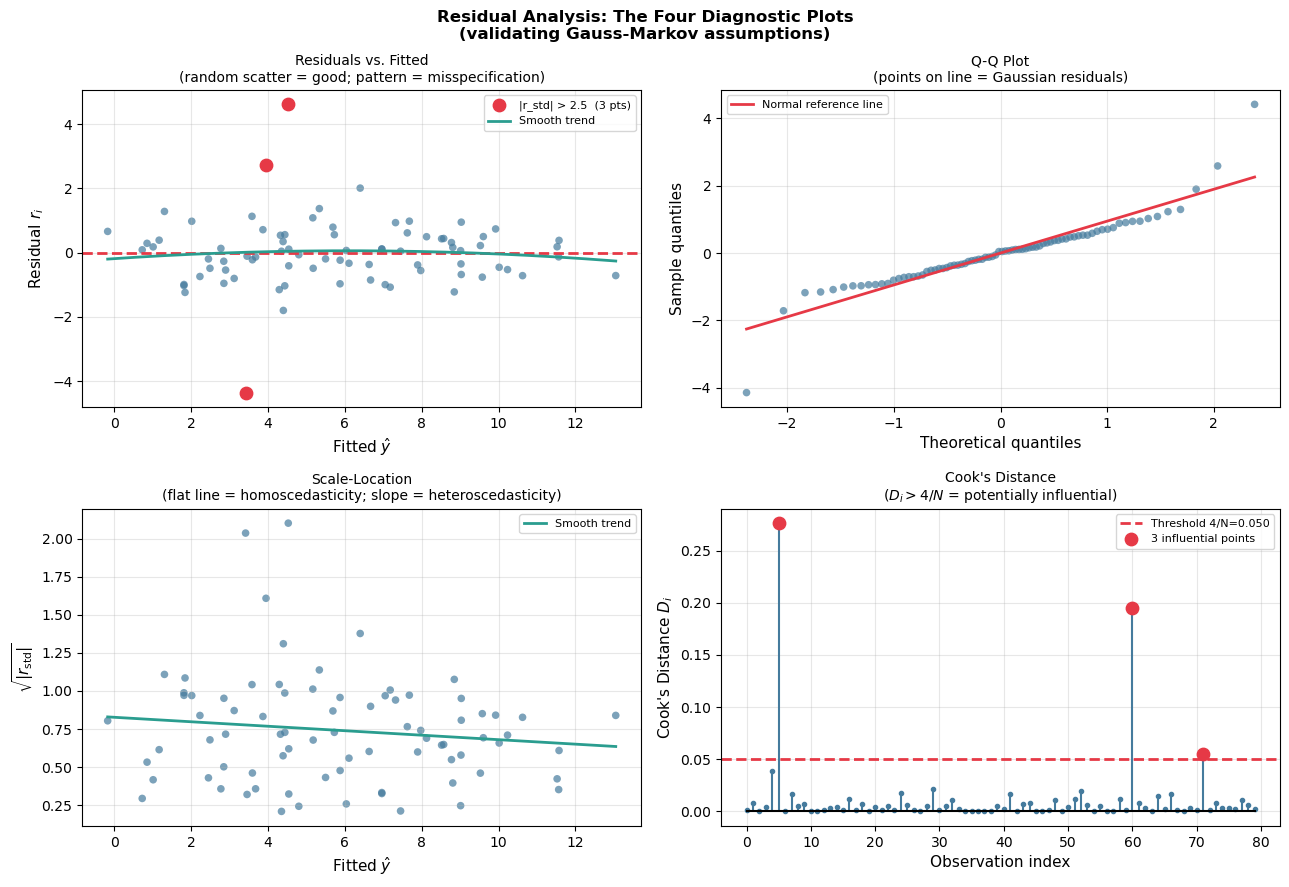

=== Residual Diagnostics Summary ===
Mean of residuals:       0.000000  (should be ~0)
Std of residuals:        1.0470  (estimate of sigma)
Shapiro-Wilk p-value:    0.0000  (> 0.05 = cannot reject normality)
Leverage range:          [0.0128, 0.1122]  (high > 2*(d+1)/N = 0.0750)
Influential (Cook > 4/N):3 observations  [ 5 60 71]


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
N, d = 80, 2
X_raw = np.column_stack([np.random.uniform(0,4,N), np.random.normal(0,1,N)])
w_true = np.array([1.0, 2.5, -1.2])
eps = np.random.normal(0, 0.8, N)
X = np.hstack([np.ones((N,1)), X_raw])
y = X @ w_true + eps

# Introduce a few outliers for illustration
y[5]  += 5.0   # outlier
y[60] -= 4.5   # outlier

w_hat = np.linalg.lstsq(X, y, rcond=None)[0]
y_hat = X @ w_hat
r     = y - y_hat
H     = X @ np.linalg.inv(X.T@X) @ X.T
h_ii  = np.diag(H)                      # leverage
sigma2_hat = np.sum(r**2) / (N - d - 1) # unbiased estimate

# Standardized residuals
r_std = r / (np.sqrt(sigma2_hat) * np.sqrt(1 - h_ii + 1e-10))

# Cook's distance
cooks = (r_std**2 / (d+1)) * (h_ii / (1 - h_ii + 1e-10))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1) Residuals vs Fitted
ax = axes[0,0]
ax.scatter(y_hat, r, s=30, color='#457B9D', alpha=0.7, edgecolors='none')
ax.axhline(0, color='#E63946', lw=2, linestyle='--')
idx_out = np.where(np.abs(r_std) > 2.5)[0]
ax.scatter(y_hat[idx_out], r[idx_out], s=80, color='#E63946', zorder=5,
           label=f'|r_std| > 2.5  ({len(idx_out)} pts)')
from numpy.polynomial import polynomial as P
z = np.polyfit(y_hat, r, 2)
x_sm = np.linspace(y_hat.min(), y_hat.max(), 200)
ax.plot(x_sm, np.polyval(z, x_sm), '#2A9D8F', lw=2, label='Smooth trend')
ax.set_xlabel(r'Fitted $\hat{y}$', fontsize=11); ax.set_ylabel('Residual $r_i$', fontsize=11)
ax.set_title('Residuals vs. Fitted\n(random scatter = good; pattern = misspecification)', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 2) Q-Q plot
ax2 = axes[0,1]
(osm, osr), (slope, intercept, _) = stats.probplot(r_std, dist='norm')
ax2.scatter(osm, osr, s=30, color='#457B9D', alpha=0.7, edgecolors='none')
x_qq = np.array([osm.min(), osm.max()])
ax2.plot(x_qq, slope*x_qq + intercept, '#E63946', lw=2, label='Normal reference line')
ax2.set_xlabel('Theoretical quantiles', fontsize=11)
ax2.set_ylabel('Sample quantiles', fontsize=11)
ax2.set_title('Q-Q Plot\n(points on line = Gaussian residuals)', fontsize=10)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# 3) Scale-Location
ax3 = axes[1,0]
ax3.scatter(y_hat, np.sqrt(np.abs(r_std)), s=30, color='#457B9D', alpha=0.7, edgecolors='none')
z2 = np.polyfit(y_hat, np.sqrt(np.abs(r_std)), 1)
ax3.plot(x_sm, np.polyval(z2, x_sm), '#2A9D8F', lw=2, label='Smooth trend')
ax3.set_xlabel(r'Fitted $\hat{y}$', fontsize=11)
ax3.set_ylabel(r'$\sqrt{|r_{\mathrm{std}}|}$', fontsize=11)
ax3.set_title('Scale-Location\n(flat line = homoscedasticity; slope = heteroscedasticity)', fontsize=10)
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# 4) Cook's distance
ax4 = axes[1,1]
markerline, stemlines, baseline = ax4.stem(range(N), cooks, linefmt='#457B9D',
                                            markerfmt='o', basefmt='k-')
markerline.set_markersize(3)
thresh = 4/N
ax4.axhline(thresh, color='#E63946', lw=2, linestyle='--', label=f'Threshold 4/N={thresh:.3f}')
influential = np.where(cooks > thresh)[0]
ax4.scatter(influential, cooks[influential], s=80, color='#E63946', zorder=5,
            label=f'{len(influential)} influential points')
ax4.set_xlabel('Observation index', fontsize=11)
ax4.set_ylabel("Cook's Distance $D_i$", fontsize=11)
ax4.set_title("Cook's Distance\n($D_i > 4/N$ = potentially influential)", fontsize=10)
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

plt.suptitle('Residual Analysis: The Four Diagnostic Plots\n'
             '(validating Gauss-Markov assumptions)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('=== Residual Diagnostics Summary ===')
print(f'Mean of residuals:       {r.mean():.6f}  (should be ~0)')
print(f'Std of residuals:        {r.std():.4f}  (estimate of sigma)')
_, p_normality = stats.shapiro(r[:50])  # Shapiro-Wilk on first 50
print(f'Shapiro-Wilk p-value:    {p_normality:.4f}  (> 0.05 = cannot reject normality)')
print(f'Leverage range:          [{h_ii.min():.4f}, {h_ii.max():.4f}]  (high > 2*(d+1)/N = {2*(d+1)/N:.4f})')
print(f'Influential (Cook > 4/N):{len(influential)} observations  {influential}')


---
## 14. Multicollinearity: Causes, Diagnosis, and Remedy

> *References: Belsley, Kuh & Welsch — Regression Diagnostics, Ch. 3 [8]; Golub & Van Loan — Matrix Computations [5]*

**Multicollinearity** occurs when two or more columns of the Design Matrix $\mathbf{X}$ are nearly linearly dependent. This is one of the most common and damaging problems in linear regression.

### Mathematical Consequence

If $\mathbf{x}_j \approx \sum_{k\neq j} c_k \mathbf{x}_k$, the matrix $\mathbf{X}^T\mathbf{X}$ is nearly singular:

$$\det(\mathbf{X}^T\mathbf{X}) \approx 0 \implies \|(\mathbf{X}^T\mathbf{X})^{-1}\|_2 \to \infty$$

From the Gauss-Markov covariance formula $\text{Cov}(\mathbf{w}^*)=\sigma^2(\mathbf{X}^T\mathbf{X})^{-1}$, the variance of each estimated weight **explodes**:

$$\text{Var}(\hat{w}_j) = \sigma^2 [(\mathbf{X}^T\mathbf{X})^{-1}]_{jj} \to \infty$$

OLS remains **unbiased** (Gauss-Markov), but the estimates become **extremely unstable** — small perturbations in the data produce wildly different $\hat{\mathbf{w}}$.

### Diagnosis: Variance Inflation Factor (VIF)

The **VIF** of feature $j$ measures how much the variance of $\hat{w}_j$ is inflated due to collinearity:

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

where $R_j^2$ is the $R^2$ from regressing feature $j$ on all other features. Interpretation:

| VIF | Interpretation |
|-----|----------------|
| $1$ | No collinearity |
| $1$–$5$ | Moderate (usually acceptable) |
| $5$–$10$ | High (potential problem) |
| $> 10$ | Severe collinearity |

### Diagnosis: Condition Number

The **condition number** of $\mathbf{X}^T\mathbf{X}$ is:

$$\kappa(\mathbf{X}^T\mathbf{X}) = \frac{\sigma_{\max}^2}{\sigma_{\min}^2}$$

A large $\kappa$ signals multicollinearity and numerical instability. The spectral analysis from Section 11 directly shows this: near-zero eigenvalues correspond to near-collinear directions.

### Remedy: Ridge Regression

Adding $\lambda\mathbf{I}$ replaces every eigenvalue $\sigma_j^2$ with $\sigma_j^2+\lambda$, making the smallest eigenvalues $>0$ and bounding the condition number:

$$\kappa(\mathbf{X}^T\mathbf{X}+\lambda\mathbf{I}) = \frac{\sigma_{\max}^2+\lambda}{\sigma_{\min}^2+\lambda} \ll \kappa(\mathbf{X}^T\mathbf{X})$$

This **directly connects** multicollinearity (Section 14) → instability → Ridge (Section 11) → spectral shift — closing the loop of the entire notebook.


=== VIF Analysis ===
   Feature |   VIF (no coll.) |   VIF (high coll.)
--------------------------------------------------
  x_0      |             1.02 |             584.56
  x_1      |             1.01 |               1.01
  x_2      |             1.03 |             584.48

Condition number X1^T X1: 1.91e+00
Condition number X2^T X2: 2.34e+03


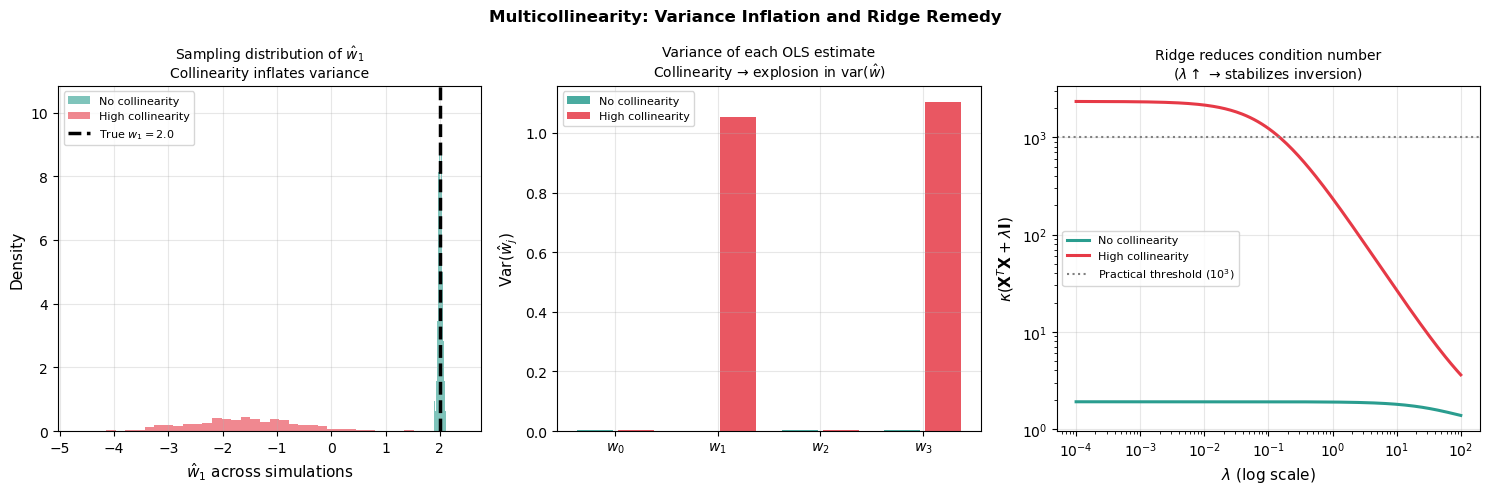

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(99)
N = 100

# === Scenario 1: No collinearity ===
X1 = np.random.randn(N, 3)

# === Scenario 2: High collinearity ===
X2 = X1.copy()
X2[:,2] = X2[:,0] * 0.98 + np.random.normal(0, 0.05, N)  # x2 ≈ x0

w_true = np.array([2.0, -1.5, 1.0])

def fit_ols(X, y):
    X_aug = np.hstack([np.ones((len(y),1)), X])
    return np.linalg.lstsq(X_aug, y, rcond=None)[0]

def compute_vif(X):
    vifs = []
    for j in range(X.shape[1]):
        X_aug = np.hstack([np.ones((X.shape[0],1)), X])
        X_j   = X[:,j]
        X_rest = np.hstack([X_aug[:,:j+1], X_aug[:,j+2:]])  # all except feature j
        r2 = LinearRegression().fit(X_rest, X_j).score(X_rest, X_j)
        vifs.append(1/(1-r2) if r2 < 1 else np.inf)
    return vifs

# Monte Carlo: variance of estimates
n_mc = 500
w_mc1, w_mc2 = [], []
for _ in range(n_mc):
    y = np.hstack([np.ones((N,1)), X1]) @ np.array([0.5]+list(w_true)) + np.random.normal(0,0.5,N)
    w_mc1.append(fit_ols(X1, y))
    w_mc2.append(fit_ols(X2, y))
w_mc1 = np.array(w_mc1); w_mc2 = np.array(w_mc2)

print('=== VIF Analysis ===')
vif1 = compute_vif(X1); vif2 = compute_vif(X2)
print(f'{"Feature":>10} | {"VIF (no coll.)": >16} | {"VIF (high coll.)": >18}')
print('-'*50)
for j, (v1, v2) in enumerate(zip(vif1, vif2)):
    print(f'  x_{j}      | {v1:>16.2f} | {v2:>18.2f}')

X1_aug = np.hstack([np.ones((N,1)), X1])
X2_aug = np.hstack([np.ones((N,1)), X2])
print(f'\nCondition number X1^T X1: {np.linalg.cond(X1_aug.T@X1_aug):.2e}')
print(f'Condition number X2^T X2: {np.linalg.cond(X2_aug.T@X2_aug):.2e}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sampling distributions
ax = axes[0]
ax.hist(w_mc1[:,1], bins=40, alpha=0.6, color='#2A9D8F', density=True, label='No collinearity')
ax.hist(w_mc2[:,1], bins=40, alpha=0.6, color='#E63946', density=True, label='High collinearity')
ax.axvline(w_true[0], color='black', lw=2.5, linestyle='--', label=f'True $w_1={w_true[0]}$')
ax.set_xlabel('$\\hat{w}_1$ across simulations', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Sampling distribution of $\\hat{w}_1$\nCollinearity inflates variance', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Variance comparison
ax2 = axes[1]
labels = ['$w_0$','$w_1$','$w_2$','$w_3$']
x_pos  = np.arange(4)
ax2.bar(x_pos-0.2, np.var(w_mc1, axis=0), 0.35, color='#2A9D8F', alpha=0.85, label='No collinearity')
ax2.bar(x_pos+0.2, np.var(w_mc2, axis=0), 0.35, color='#E63946', alpha=0.85, label='High collinearity')
ax2.set_xticks(x_pos); ax2.set_xticklabels(labels, fontsize=10)
ax2.set_ylabel('Var($\\hat{w}_j$)', fontsize=11)
ax2.set_title('Variance of each OLS estimate\nCollinearity → explosion in var($\\hat{w}$)', fontsize=10)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# Ridge stabilization
lambdas = np.logspace(-4, 2, 200)
conds_no  = [np.linalg.cond(X1_aug.T@X1_aug + lam*np.eye(4)) for lam in lambdas]
conds_col = [np.linalg.cond(X2_aug.T@X2_aug + lam*np.eye(4)) for lam in lambdas]

ax3 = axes[2]
ax3.loglog(lambdas, conds_no,  '#2A9D8F', lw=2.2, label='No collinearity')
ax3.loglog(lambdas, conds_col, '#E63946', lw=2.2, label='High collinearity')
ax3.axhline(1e3, color='gray', lw=1.5, linestyle=':', label='Practical threshold ($10^3$)')
ax3.set_xlabel(r'$\lambda$ (log scale)', fontsize=11)
ax3.set_ylabel(r'$\kappa(\mathbf{X}^T\mathbf{X}+\lambda\mathbf{I})$', fontsize=11)
ax3.set_title('Ridge reduces condition number\n($\\lambda\\uparrow$ → stabilizes inversion)', fontsize=10)
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

plt.suptitle('Multicollinearity: Variance Inflation and Ridge Remedy', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 15. Full Comparison: Linear vs. Polynomial vs. Ridge

All three models side by side on the same dataset — fit quality, generalization, and numerical stability.


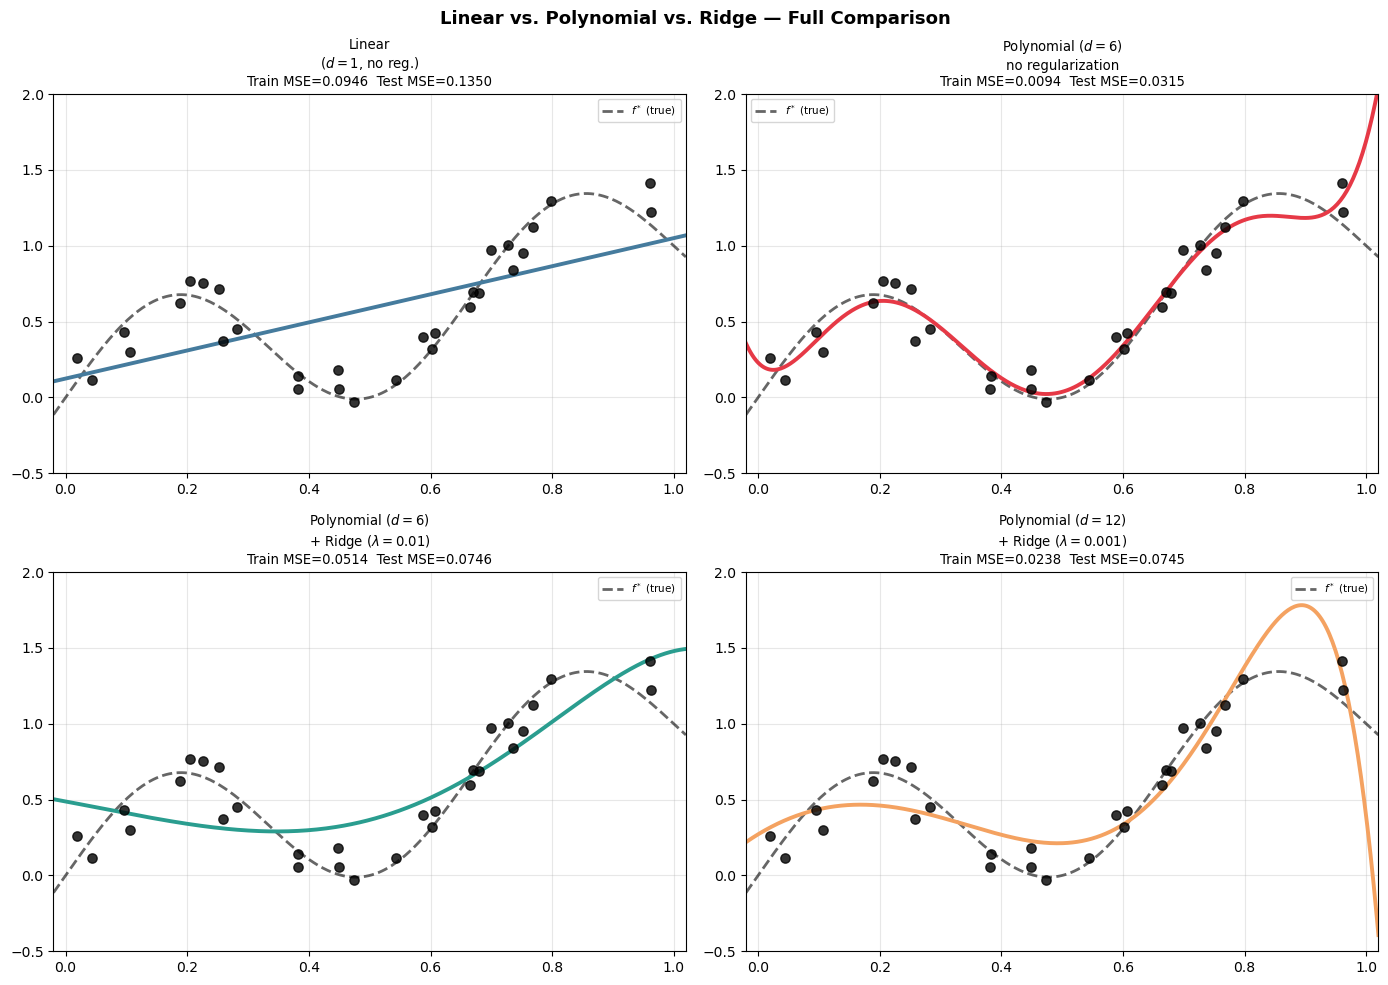

Model                                              |  Train MSE |   Test MSE
----------------------------------------------------------------------------
Linear
($d=1$, no reg.)                            |     0.0946 |     0.1350
Polynomial ($d=6$)
no regularization               |     0.0094 |     0.0315
Polynomial ($d=6$)
+ Ridge ($\lambda=0.01$)        |     0.0514 |     0.0746
Polynomial ($d=12$)
+ Ridge ($\lambda=0.001$)      |     0.0238 |     0.0745


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(2024)
f_true = lambda x: 0.5*np.sin(3*np.pi*x) + x
N_tr   = 30
x_tr   = np.sort(np.random.uniform(0,1,N_tr))
y_tr   = f_true(x_tr) + np.random.normal(0, 0.15, N_tr)
x_te   = np.sort(np.random.uniform(0,1,100))
y_te   = f_true(x_te) + np.random.normal(0, 0.15, 100)
x_plot = np.linspace(-0.02, 1.02, 400)

models = {
    'Linear\n($d=1$, no reg.)':           make_pipeline(PolynomialFeatures(1), Ridge(alpha=0)),
    'Polynomial ($d=6$)\nno regularization': make_pipeline(PolynomialFeatures(6), Ridge(alpha=0)),
    'Polynomial ($d=6$)\n+ Ridge ($\\lambda=0.01$)': make_pipeline(PolynomialFeatures(6), Ridge(alpha=0.01)),
    'Polynomial ($d=12$)\n+ Ridge ($\\lambda=0.001$)': make_pipeline(PolynomialFeatures(12), Ridge(alpha=0.001)),
}
colors_m = ['#457B9D','#E63946','#2A9D8F','#F4A261']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
results = []
for ax, (name, model), color in zip(axes.flat, models.items(), colors_m):
    model.fit(x_tr.reshape(-1,1), y_tr)
    tr_mse = mean_squared_error(y_tr, model.predict(x_tr.reshape(-1,1)))
    te_mse = mean_squared_error(y_te, model.predict(x_te.reshape(-1,1)))
    results.append((name.replace('\\n',' '), tr_mse, te_mse))
    ax.plot(x_plot, f_true(x_plot), 'k--', lw=2, alpha=0.6, label=r'$f^*$ (true)')
    ax.scatter(x_tr, y_tr, s=45, color='black', zorder=5, alpha=0.8)
    ax.plot(x_plot, np.clip(model.predict(x_plot.reshape(-1,1)),-0.5,2.), color=color, lw=2.8)
    ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.5,2.0)
    ax.set_title(f'{name}\nTrain MSE={tr_mse:.4f}  Test MSE={te_mse:.4f}', fontsize=9.5)
    ax.legend(fontsize=7.5); ax.grid(True, alpha=0.3)

plt.suptitle('Linear vs. Polynomial vs. Ridge — Full Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'{"Model":<50} | {"Train MSE":>10} | {"Test MSE":>10}')
print('-'*76)
for name, tr, te in results:
    print(f'{name:<50} | {tr:>10.4f} | {te:>10.4f}')


---
## Summary

| Concept | Key Formula | Core Insight |
|---------|-------------|-------------|
| Linear model | $\hat{y}=\mathbf{w}^T\mathbf{x}$ (augmented) | Affine map via bias trick |
| RSS | $L=\|\mathbf{y}-\mathbf{X}\mathbf{w}\|_2^2$ | Convex, differentiable |
| ERM | $\hat{R}_N=\frac{1}{N}\sum_i L_i\to R(f)$ | LLN approximation of true risk |
| Normal Equations | $\mathbf{w}^*=(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ | Exact in $\mathcal{O}(d^3)$ |
| Hat Matrix | $\mathbf{H}=\mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$, $\mathbf{H}^2=\mathbf{H}$, $h_{ii}=$ leverage | Symmetric, idempotent |
| MLE $\equiv$ LSQ | $\arg\max\ell=\arg\min\text{RSS}$ | Under Gaussian noise |
| **Gauss-Markov** | $\text{Cov}(\mathbf{w}^*)=\sigma^2(\mathbf{X}^T\mathbf{X})^{-1}$ | OLS is BLUE |
| GD | $\mathbf{w}^{(t+1)}=\mathbf{w}^{(t)}-\frac{\eta}{N}\mathbf{X}^T(\mathbf{X}\mathbf{w}^{(t)}-\mathbf{y})$ | $\mathcal{O}(Nd)$ per step |
| Vandermonde | $\mathbf{\Phi}_{ij}=x_i^{j-1}$, cond $\sim\mathcal{O}(e^d)$ | Nonlinear features, linear in $\mathbf{w}$ |
| Bias-Variance | $\mathbb{E}[R]=\sigma^2+\text{Bias}^2+\text{Var}$ | Fundamental trade-off |
| Ridge | $\mathbf{w}_{\text{Ridge}}=(\mathbf{X}^T\mathbf{X}+\lambda\mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}$ | Eigenvalue shift, invertible |
| Ridge shrinkage | $\mathbb{E}[\mathbf{w}_{\text{R}}]=\mathbf{U}\operatorname{diag}\!\left(\frac{\sigma_j^2}{\sigma_j^2+\lambda}\right)\mathbf{U}^T\mathbf{w}_{\text{true}}$ | Biased but stable |
| **Residual Analysis** | Cook's $D_i = \frac{r_i^2}{(d+1)\hat{\sigma}^2}\cdot\frac{h_{ii}}{(1-h_{ii})^2}$ | Validates Gauss-Markov assumptions |
| **VIF** | $\text{VIF}_j=\frac{1}{1-R_j^2}$ | Diagnoses multicollinearity |

---

**Next →** `07_logistic_regression.ipynb`: Sigmoid Link, Maximum Likelihood, IRLS, and Generalized Linear Models for Classification.
